# 02 · KPIs Supply Chain por País + Global
**TFM — Streaming Analytics para Supply Chain | Telecomunicaciones Multi-País**

Autora: Iliana Yazmin Pasos Gallo

---

Este notebook calcula los KPIs de Supply Chain individualmente por país y los consolida en una vista global comparativa.

| Sección | Contenido |
|---|---|
| **0** | Imports y configuración |
| **1** | Carga de datos |
| **2** | Preparación y tipos |
| **3** | KPIs por país (loop multi-país) |
| **4** | Diagnóstico Fill Rate |
| **5** | Consolidado global |
| **6** | Conclusiones |

**Entrada:** `../data/processed/datos_limpios.parquet`

**Salidas:** CSVs y graficas en `../outputs/kpis/`

> **Nota sobre inventario:** Cada registro `INVENTORY` es una fotografia (snapshot) del stock en esa fecha.
> No se acumula entre periodos. Se usa el ultimo valor para cierre y el promedio para rotacion y cobertura.


## 0 · Imports y Configuración

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# -- Estilo visual unificado con el resto del proyecto -----------------------
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#e0e0e0',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'xtick.color'      : '#a0a0b0',
    'ytick.color'      : '#a0a0b0',
    'text.color'       : '#e0e0e0',
    'grid.color'       : '#2a2d3d',
    'grid.linestyle'   : '--',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'figure.figsize'   : (13, 5),
})

INPUT_FILE = Path('../data/processed/datos_limpios.parquet')
OUTPUT_DIR = Path('../outputs/kpis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DIAS_MES = 30
PALETTE  = ['#00d4aa', '#6c63ff', '#ff6b6b', '#ffd166', '#4ecdc4',
            '#a29bfe', '#fd79a8', '#55efc4', '#fdcb6e', '#e17055']

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Mantener COLORS como alias para compatibilidad con celdas existentes
COLORS = PALETTE

print('Librerias cargadas correctamente.')


Librerias cargadas correctamente.


### Funciones auxiliares de visualizacion

In [2]:
def format_miles(ax, eje="y"):
    fmt = mticker.StrMethodFormatter('{x:,.0f}')
    if eje == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

def format_monedas(ax, eje="y"):
    fmt = mticker.StrMethodFormatter('${x:,.0f}')
    if eje == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

def format_porcentaje(ax, eje="y", escala=1.0):
    if eje == "y":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=escala))
    else:
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=escala))

def estilizar_ax(ax, titulo, xlabel="", ylabel=""):
    ax.set_title(titulo, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def etiquetar_barras(ax, formato="{:,.0f}", porcentaje=False, total=None):
    for p in ax.patches:
        valor = p.get_height()
        if valor is None or np.isnan(valor) or valor == 0:
            continue
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        if porcentaje and total and total > 0:
            txt = f"{formato.format(valor)}\n({valor/total:.1%})"
        else:
            txt = formato.format(valor)
        ax.annotate(txt, (x, y), ha="center", va="bottom",
                    fontsize=9, xytext=(0, 4), textcoords="offset points")

def etiquetar_barras_h(ax, formato="{:,.0f}"):
    for p in ax.patches:
        valor = p.get_width()
        if valor is None or np.isnan(valor) or valor == 0:
            continue
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(formato.format(valor), (x, y), ha="left", va="center",
                    fontsize=9, xytext=(5, 0), textcoords="offset points")


## 1 · Carga de Datos

In [3]:
df = pd.read_parquet(INPUT_FILE).copy()
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
display(df.head(3))


Filas: 17,140,878 | Columnas: 26


,FECHA,FECHA_VENTA_INVENTARIO,ANIO,MES,MES_NOMBRE,YEAR_MONTH,ANOMES,PAIS,TIPO_TRANSACCION,CODIGO_SKU,FAMILIA,MODELO,MARCA,TIER,ESTADO,CODIGO_BODEGA,NOMBRE_BODEGA,UBICACION,TIPO_BODEGA,VALUE,PRECIO_UNITARIO,COSTO,SOURCE_FILE,SOURCE_COUNTRY,DELIVERY_DATE,ES_OUTLIER
0,2023-02-28,20230228,2023,2,February,2023-02,202302,NI,SALES,3257,BMOBILE K390,KIT BMOBILE K390 GRAY,BMOBILE,FEATURE PHONE,EOL,1307,CD RIO BLANCO,BOD RIO BLANCO,COMERCIALIZABLE,1,12.50,12.50,DATOS_NI.CSV,NICARAGUA,"20,260,417.00",False
1,2023-02-28,20230228,2023,2,February,2023-02,202302,NI,SALES,3218,SMOOTH TANK3,KIT SNAP TANK3 BLACK,SMOOTH,FEATURE PHONE,EOL,780,CD CHINANDEGA,BOD CHINANDEGA,COMERCIALIZABLE,1,14.00,14.00,DATOS_NI.CSV,NICARAGUA,"20,260,417.00",False
2,2023-02-28,20230228,2023,2,February,2023-02,202302,NI,SALES,3214,ZTE BLADE A31 PLUS,KIT ZTE BLADE A31 PLUS BLUE,ZTE,LOW,EOL,780,CD CHINANDEGA,BOD CHINANDEGA,COMERCIALIZABLE,1,74.99,74.99,DATOS_NI.CSV,NICARAGUA,"20,260,417.00",False


## 2 · Preparación y Tipos

In [4]:
df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

for col in ["VALUE", "PRECIO_UNITARIO", "COSTO"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["PAIS","TIPO_TRANSACCION","MARCA","TIER","MODELO",
            "FAMILIA","ESTADO","CODIGO_SKU","CODIGO_BODEGA",
            "YEAR_MONTH","NOMBRE_BODEGA","UBICACION","TIPO_BODEGA"]:
    if col in df.columns:
        df[col] = df[col].astype("string")

# Columnas derivadas
df["INGRESO_TOTAL"] = df["VALUE"] * df["PRECIO_UNITARIO"]
df["ANIO"]          = df["FECHA"].dt.year
df["MES"]           = df["FECHA"].dt.month
df["YEAR_MONTH"]    = df["FECHA"].dt.to_period("M").astype("string")

df_sales     = df[df["TIPO_TRANSACCION"] == "SALES"].copy()
df_inventory = df[df["TIPO_TRANSACCION"] == "INVENTORY"].copy()
df_transits  = df[df["TIPO_TRANSACCION"] == "TRANSITS"].copy()

PAISES = sorted(df["PAIS"].dropna().unique().tolist())
print(f"Países detectados: {PAISES}")
print(f"SALES: {len(df_sales):,} | INVENTORY: {len(df_inventory):,} | TRANSITS: {len(df_transits):,}")


Países detectados: ['NI', 'PY']
SALES: 268,487 | INVENTORY: 16,699,683 | TRANSITS: 172,708


## 3 · KPIs por País

El bloque siguiente itera sobre cada pais y calcula todos los KPIs.
Los resultados se acumulan en estructuras que luego se utilizan para el consolidado global en la Seccion 5.

---

### KPIs calculados por país

- **Ventas totales**
- **Ingresos totales**
- **ASP (Average Selling Price)**
- **Sell-through Rate**
- **Crecimiento MoM y YoY (mensual y anual)**
- **Inventario de cierre**
- **DOH (Days on Hand)**
- **Stock Turnover**
- **Stockout Rate**
- **Fill Rate**
- **Top modelos y marcas**
- **Analisis por tier / segmento**

---

### Definicion de KPIs

| KPI | Formula | Interpretacion |
|---|---|---|
| **ASP** | Ingresos / Unidades | Precio promedio de venta |
| **Sell-through Rate** | Unidades vendidas / (Ventas + Inventario) | Que proporcion del stock disponible se vendio |
| **DOH** | Inventario promedio / (Ventas / 30) | Dias que dura el stock actual al ritmo de ventas |
| **Stock Turnover** | Ventas / Inventario promedio | Veces que rota el inventario en el periodo |
| **Stockout Rate** | Meses con stock=0 / Total meses | Frecuencia de quiebre de stock por SKU |
| **Fill Rate** | SKUs con venta / SKUs con inventario | Capacidad de satisfacer demanda desde stock disponible |


  PAÍS: NI
  Unidades: 134,768 | Ingresos: 12,166,448.71 | ASP: 90.28


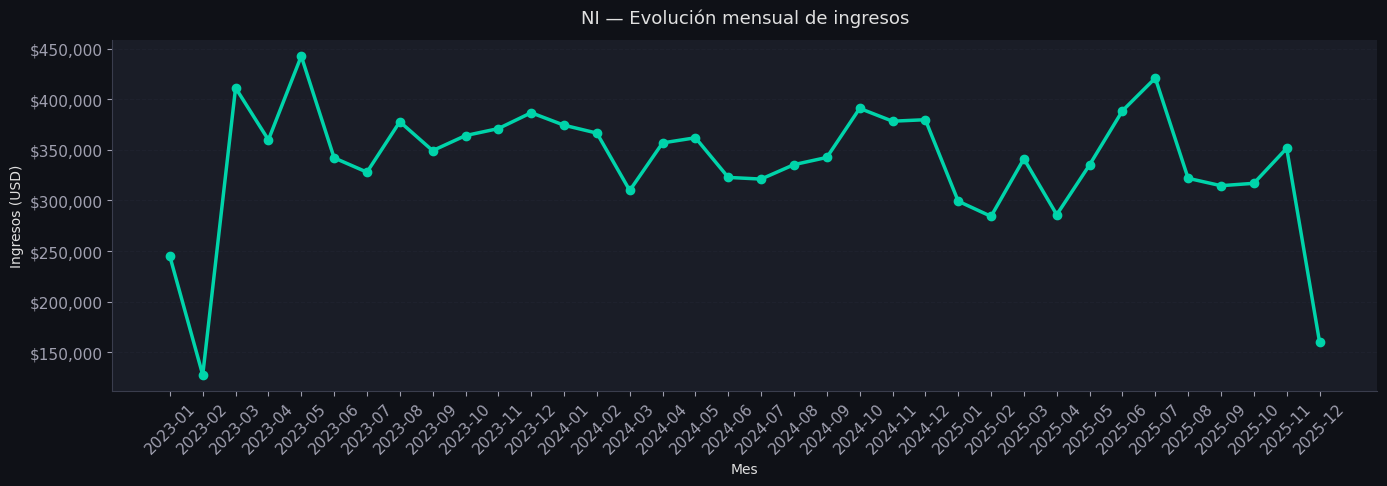

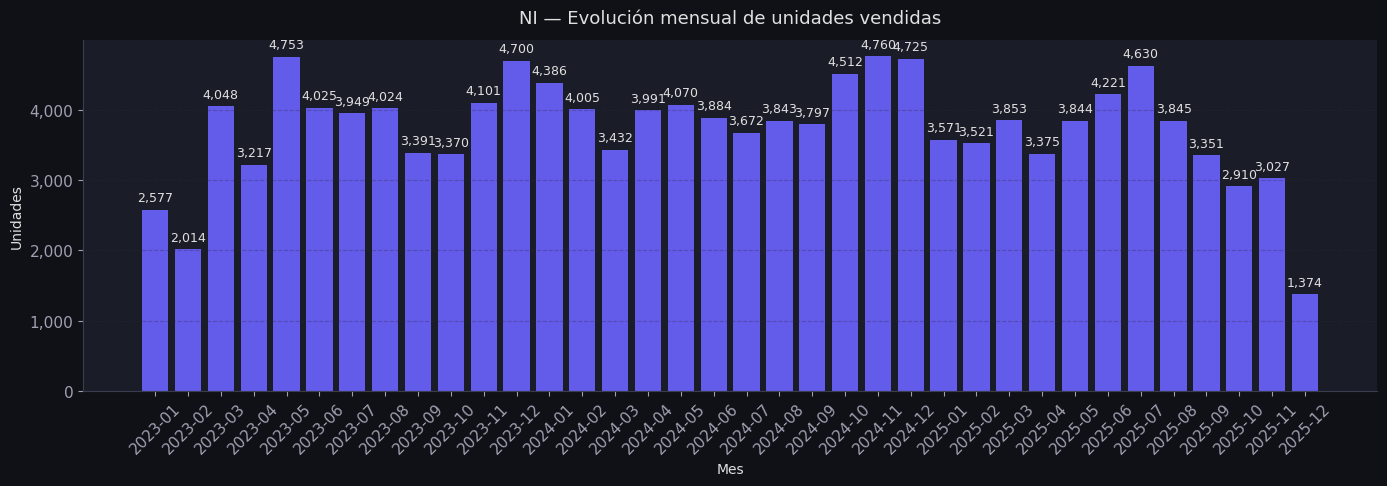

  Stockout rate promedio: 37.84%
  Fill rate promedio:     38.04%


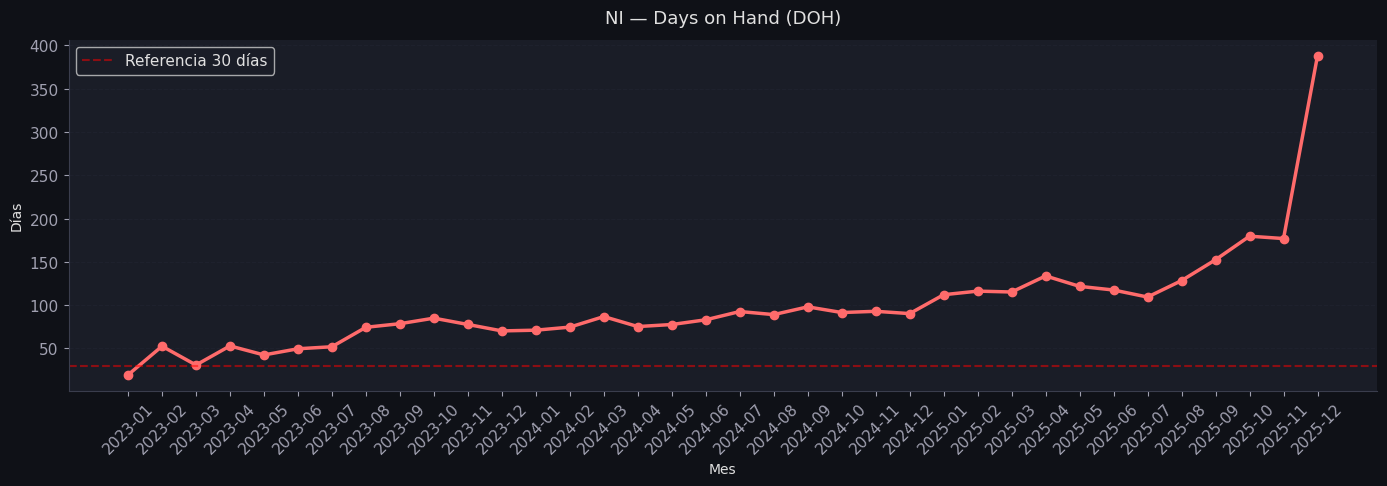

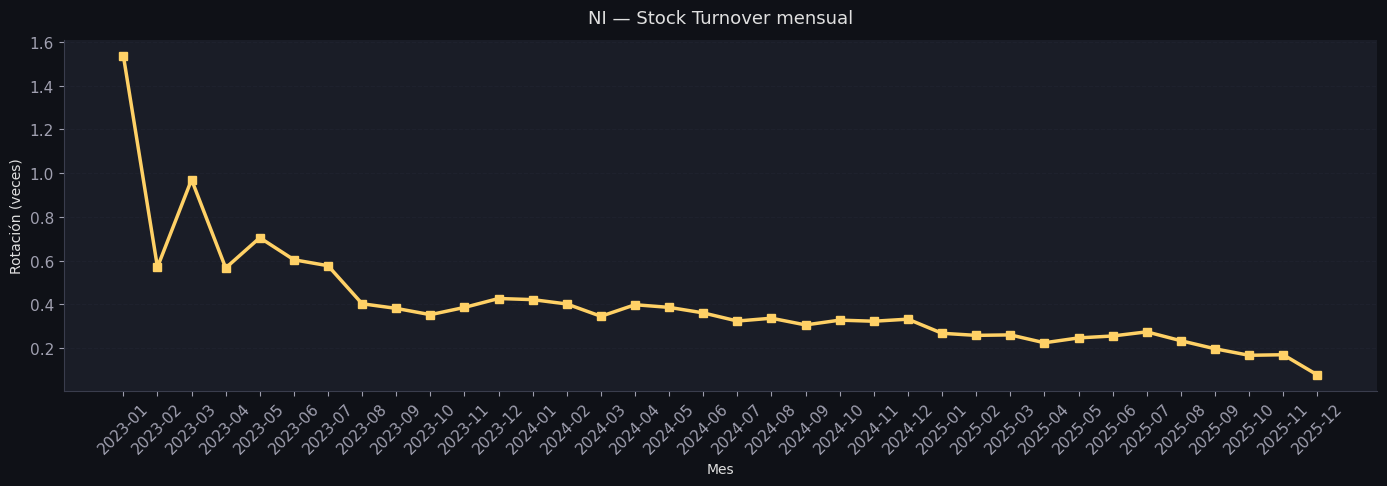

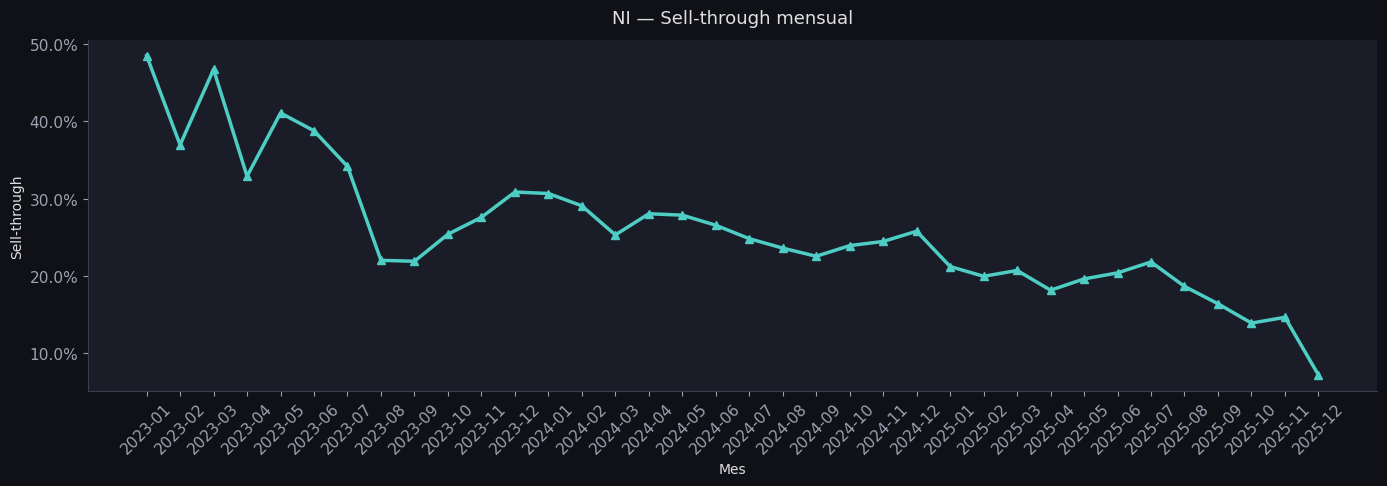

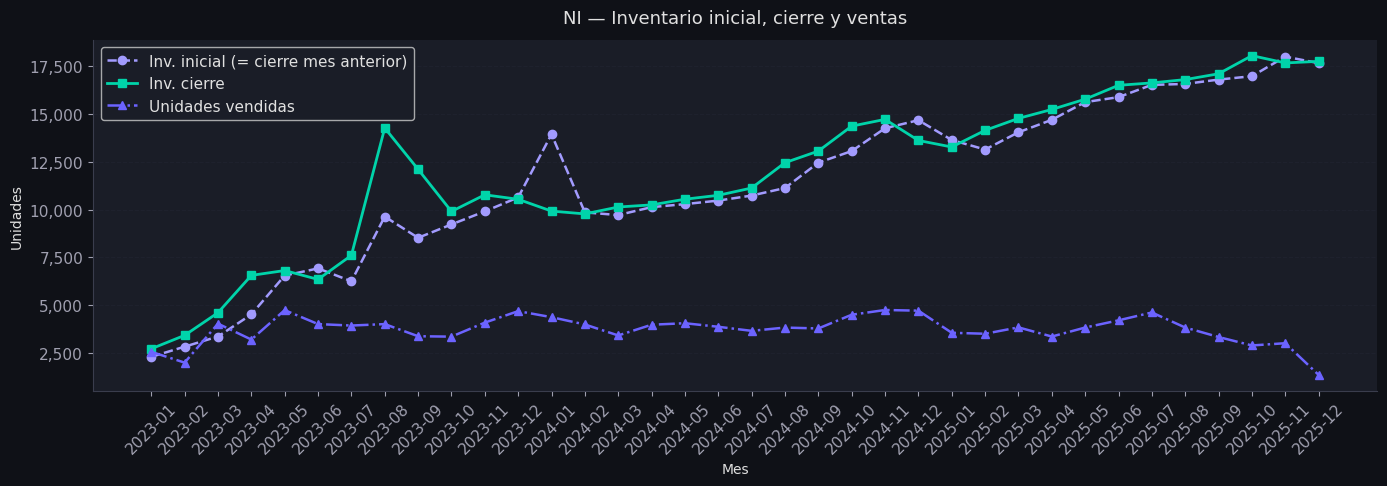

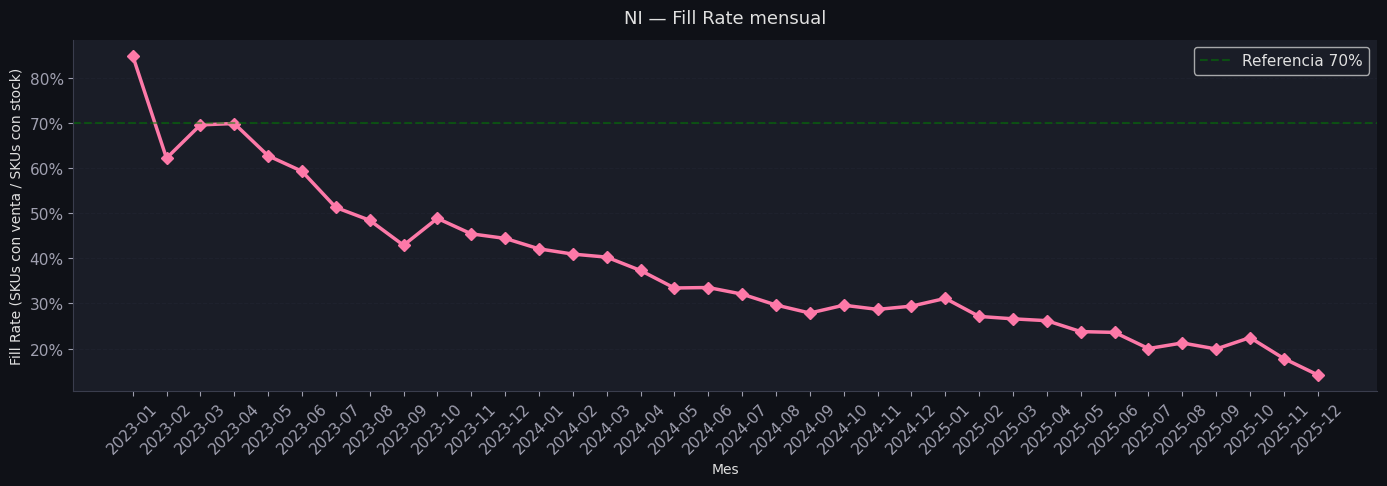

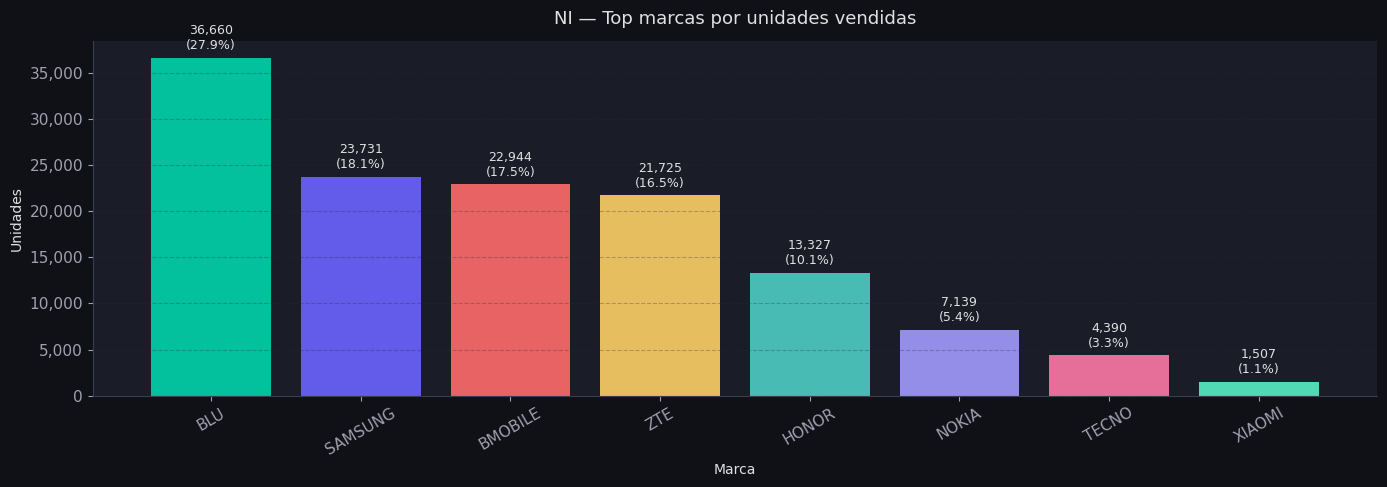

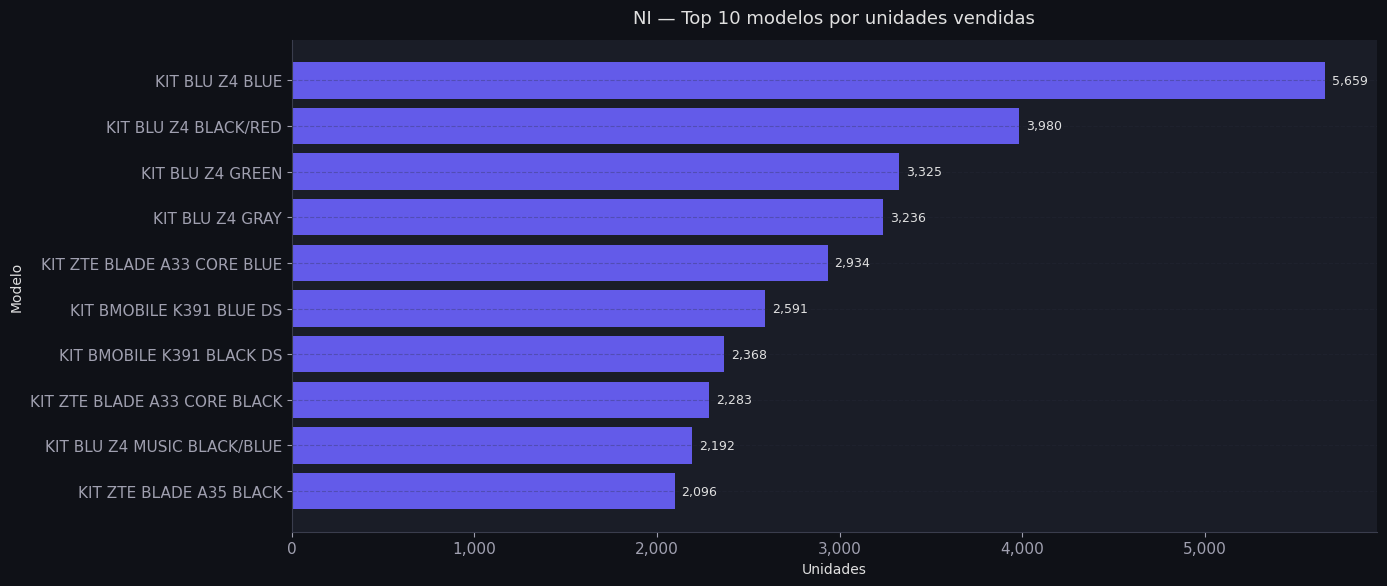

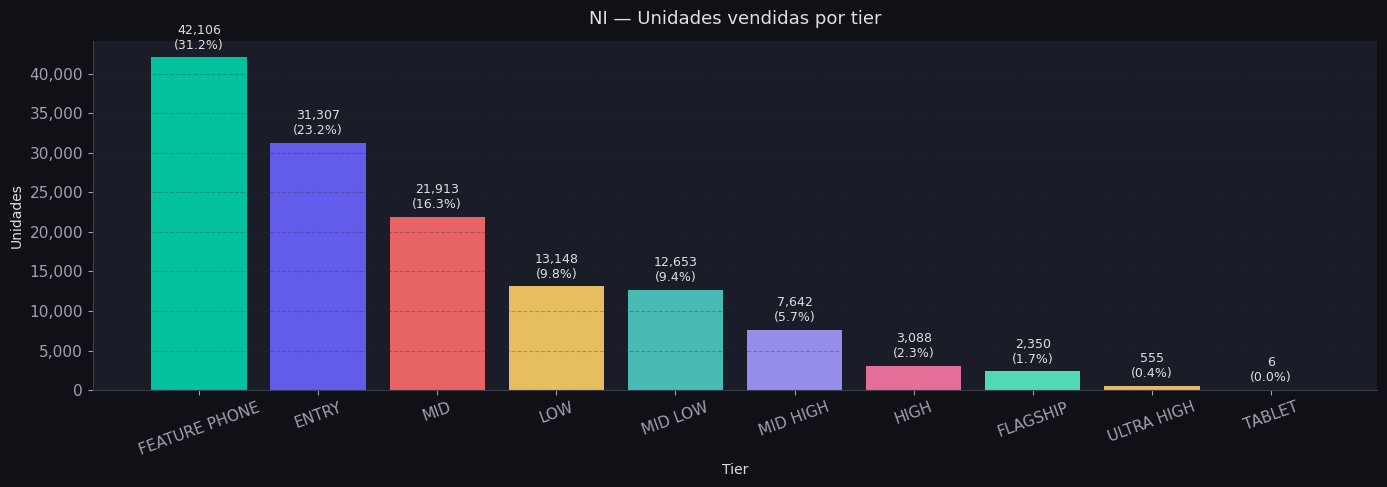

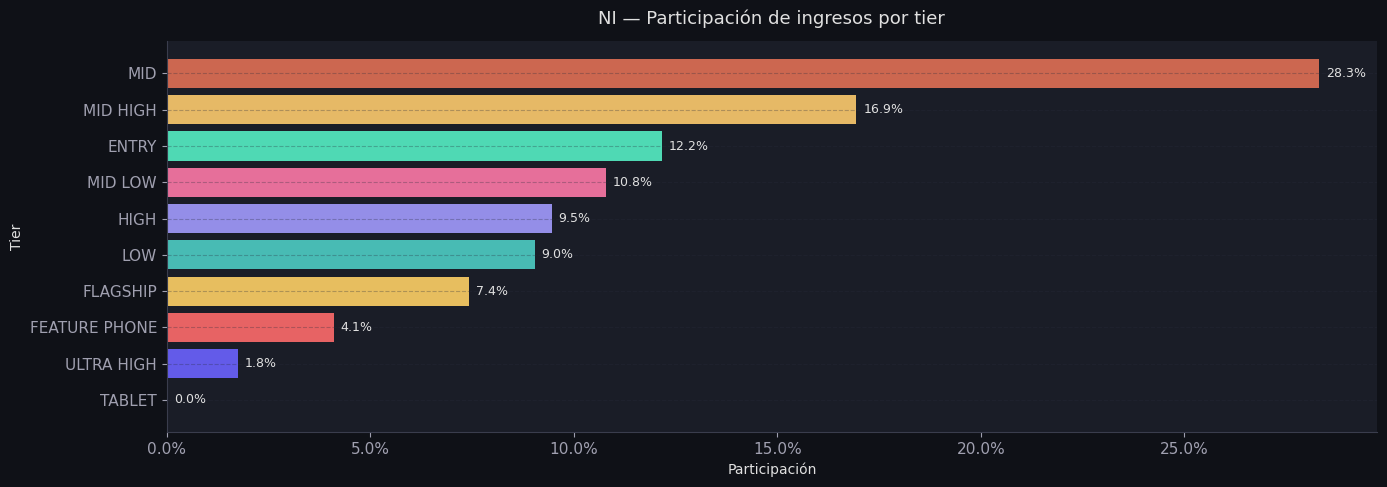

  ✓ NI completado — outputs/kpis/NI/

  PAÍS: PY
  Unidades: 260,681 | Ingresos: 30,154,300.47 | ASP: 115.68


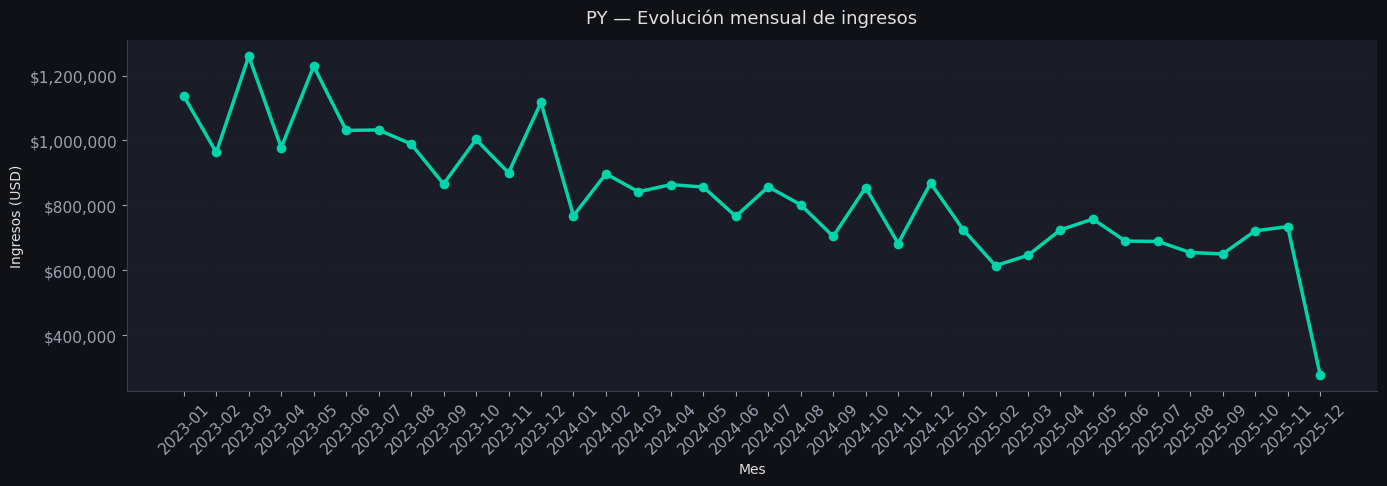

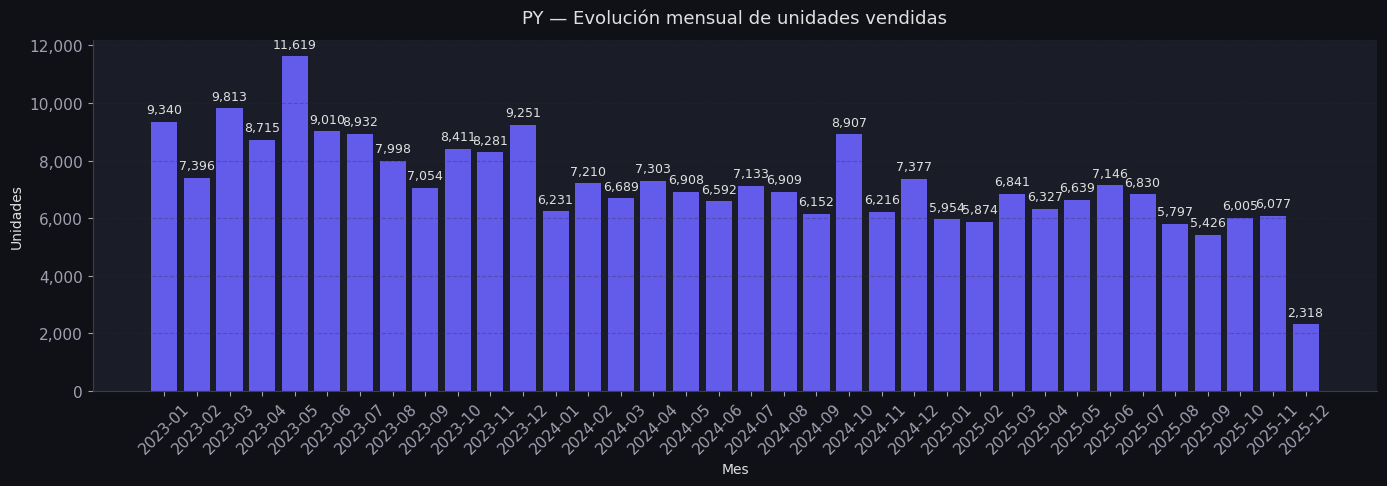

  Stockout rate promedio: 31.97%
  Fill rate promedio:     27.48%


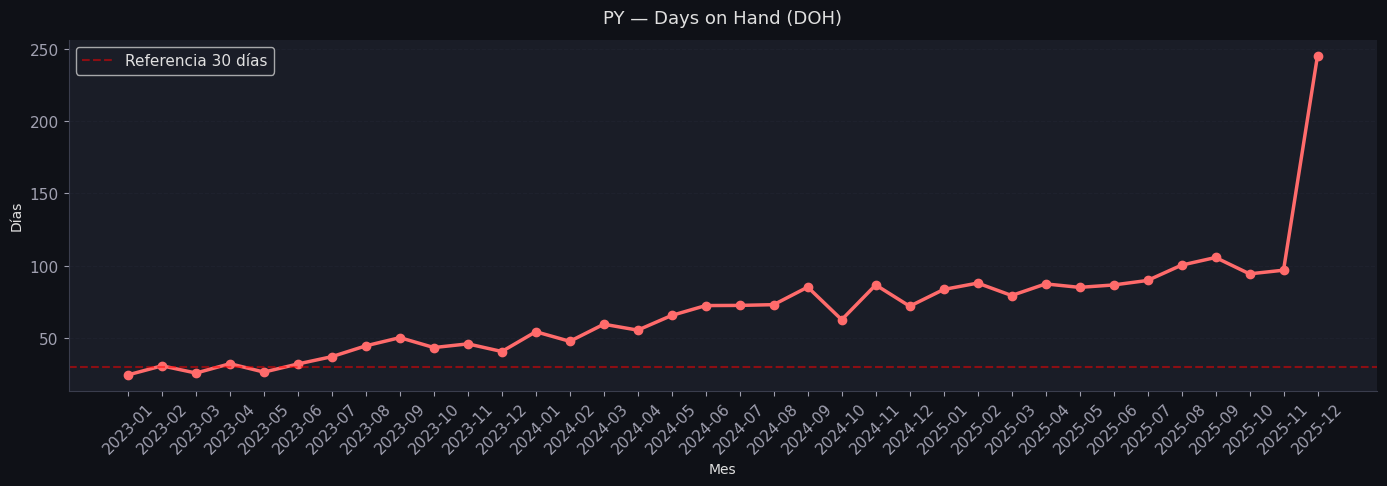

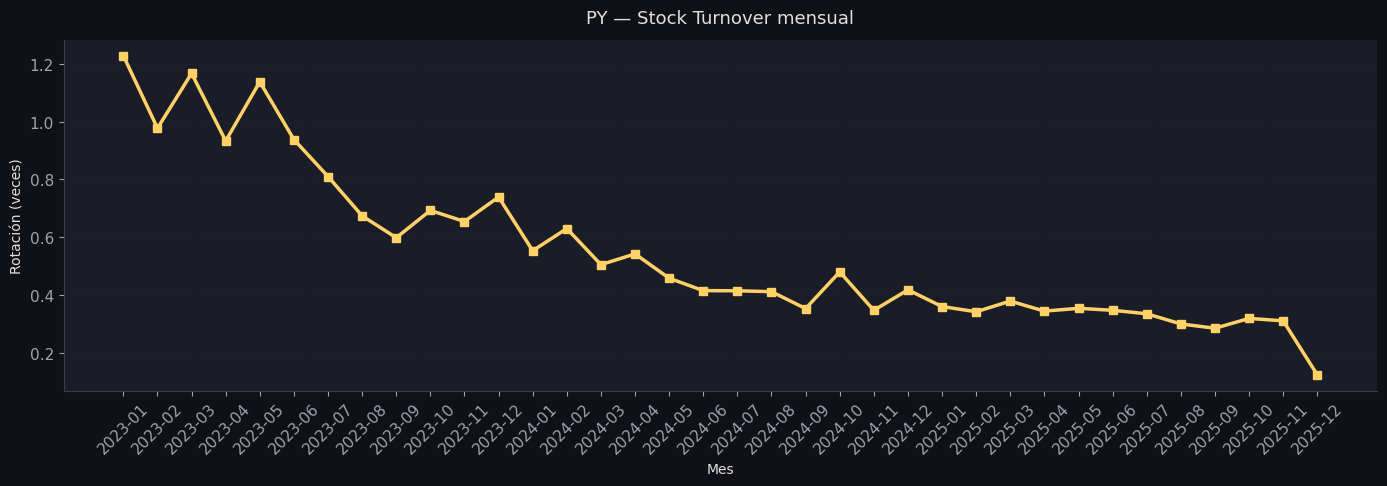

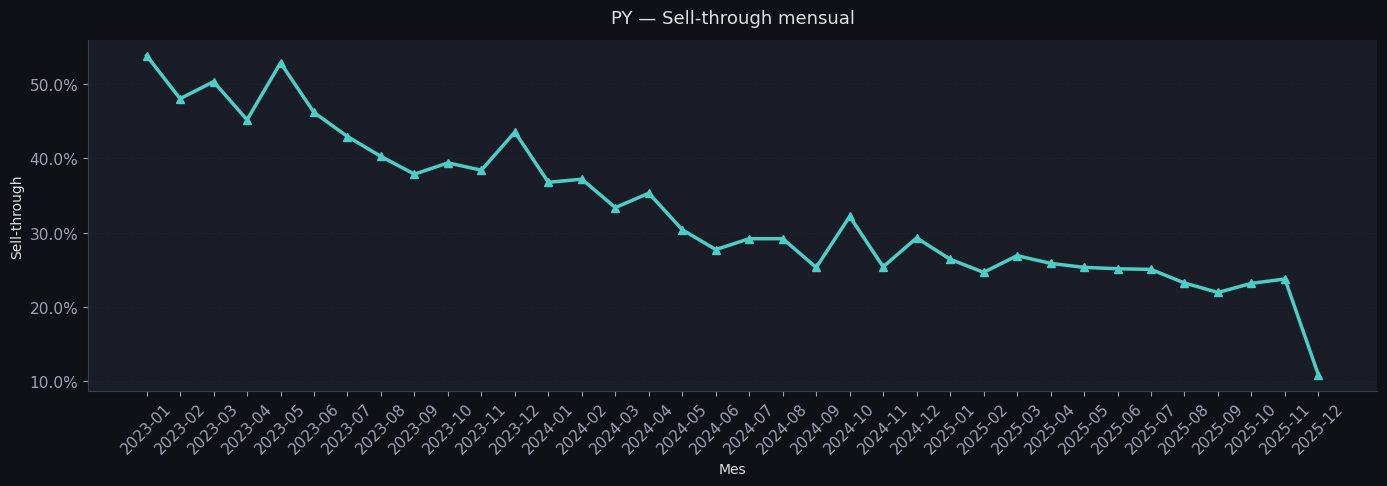

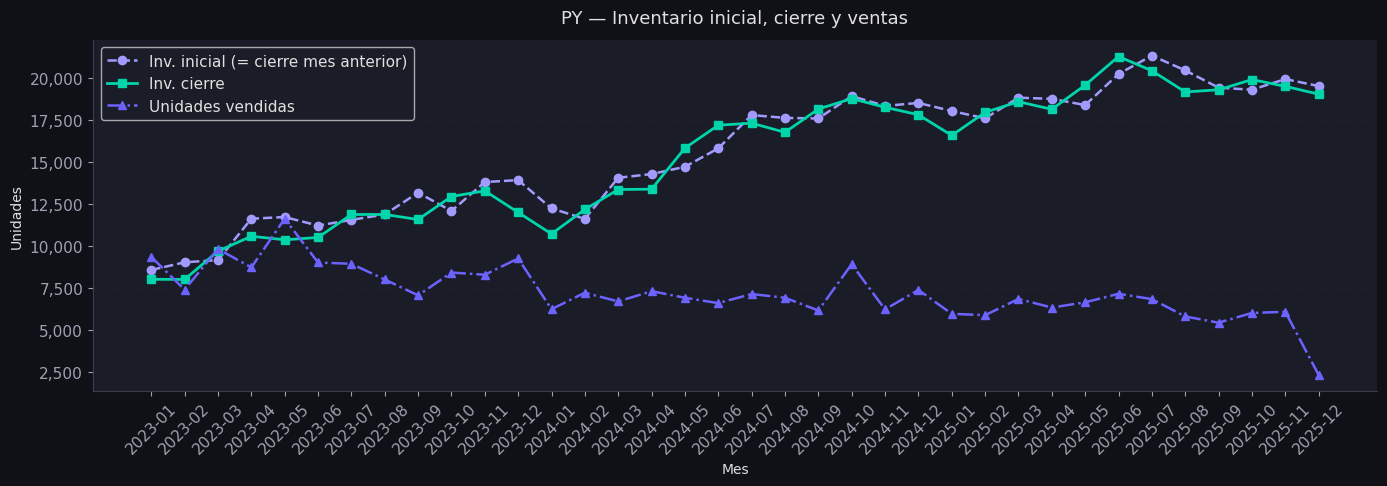

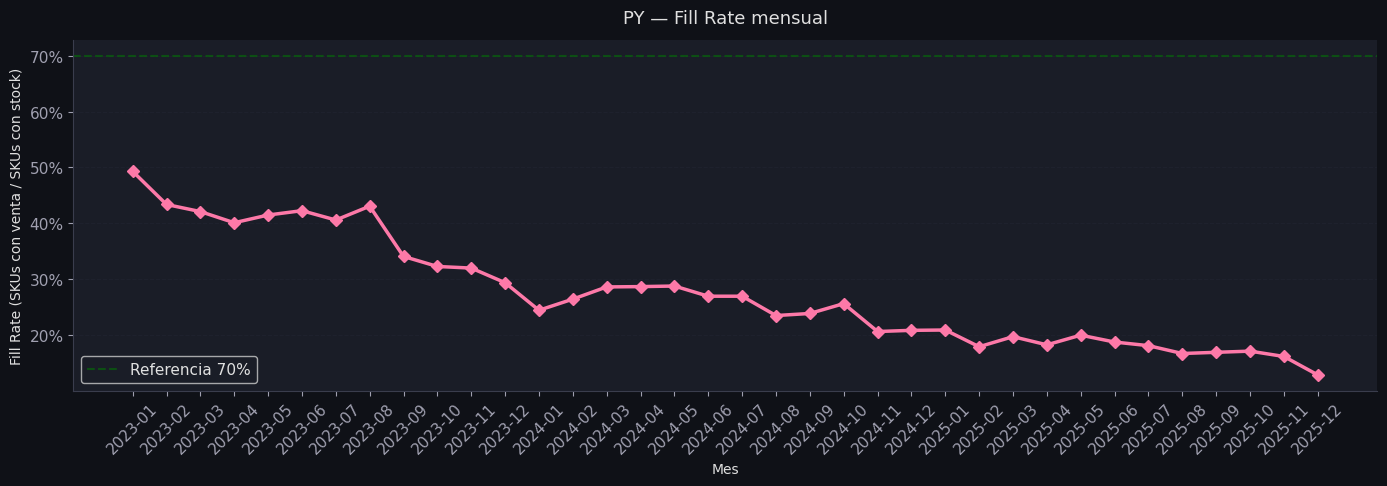

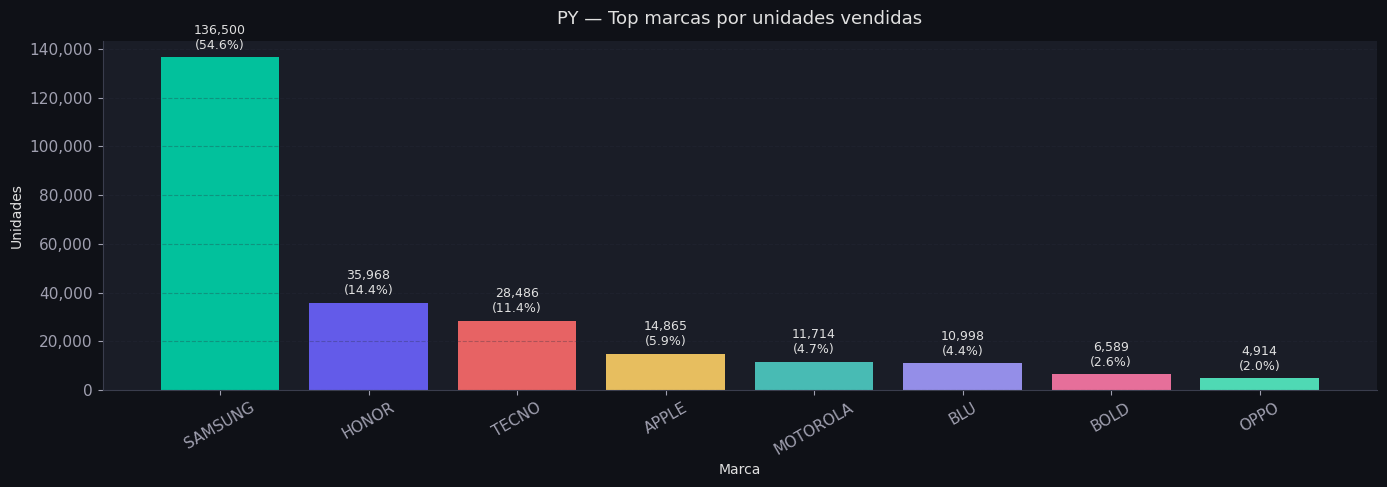

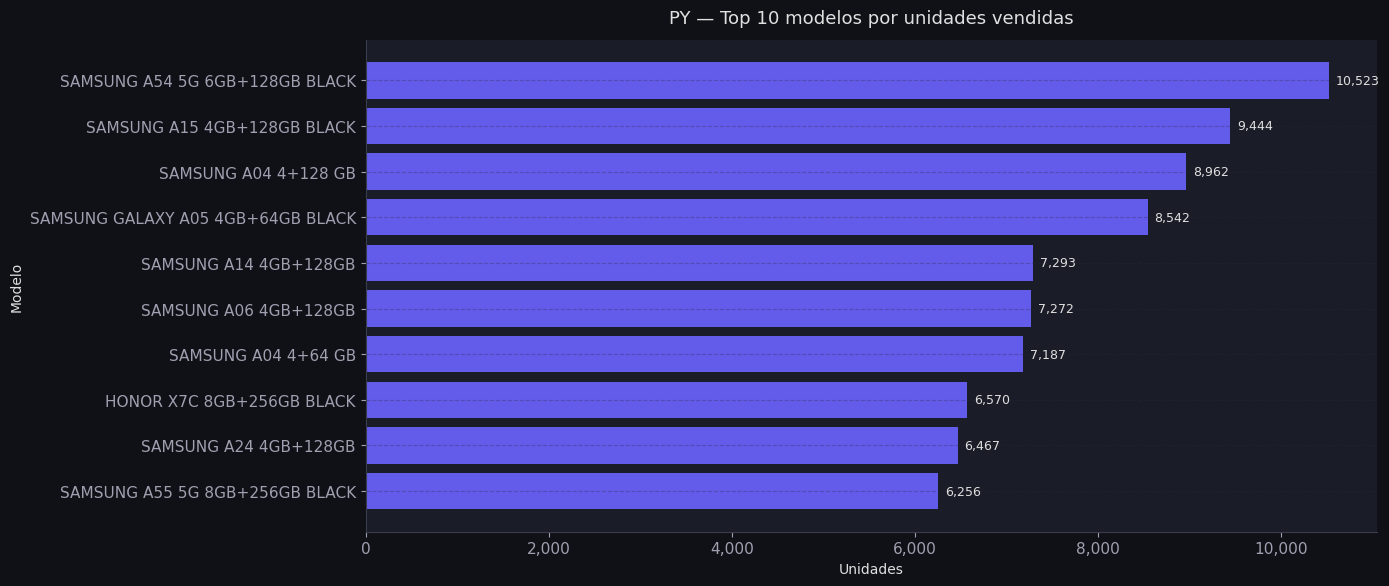

TypeError: 'value' must be an instance of str or bytes, not a pandas._libs.missing.NAType

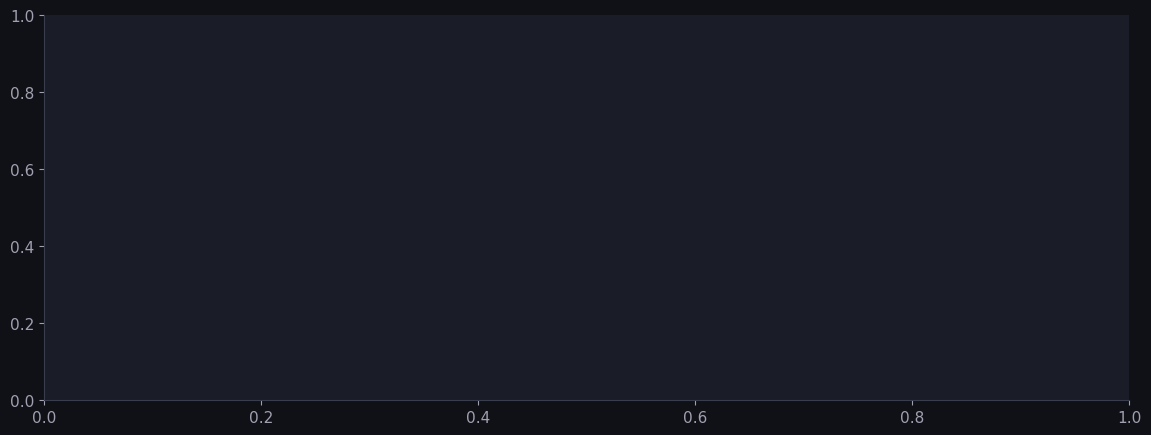

In [ ]:
# ── Acumuladores ─────────────────────────────────────────────
acum_ventas_generales = []
acum_ventas_mes       = []
acum_ventas_anio      = []
acum_kpi_inv          = []
acum_stockout         = []
acum_fill_rate        = []
acum_marca            = []
acum_modelos          = []
acum_tier             = []

# ══════════════════════════════════════════════════════════════
for pais in PAISES:
    print("=" * 60)
    print(f"  PAÍS: {pais}")
    print("=" * 60)

    s  = df_sales[df_sales["PAIS"] == pais].copy()
    iv = df_inventory[df_inventory["PAIS"] == pais].copy()
    dir_pais = OUTPUT_DIR / pais.replace(" ", "_")
    dir_pais.mkdir(parents=True, exist_ok=True)

    if len(s) == 0:
        print(f"  Sin datos de ventas para {pais}. Se omite.")
        continue

    # ── A. KPIs GENERALES DE VENTAS ──────────────────────────
    ventas_tot   = s["VALUE"].sum()
    ingresos_tot = s["INGRESO_TOTAL"].sum()
    asp          = ingresos_tot / ventas_tot if ventas_tot > 0 else np.nan
    inv_prom_g   = iv["VALUE"].mean() if len(iv) > 0 else np.nan
    sell_thru    = (ventas_tot / (ventas_tot + inv_prom_g)
                   if (pd.notna(inv_prom_g) and inv_prom_g > 0) else np.nan)

    res_ventas = pd.DataFrame({
        "PAIS"  : [pais] * 4,
        "KPI"   : ["Unidades vendidas", "Ingresos totales", "ASP", "Sell-through Rate"],
        "VALOR" : [ventas_tot, ingresos_tot, asp, sell_thru],
        "UNIDAD": ["ud", "USD", "USD/ud", "%"]
    })
    res_ventas.to_csv(dir_pais / "kpi_ventas_generales.csv", index=False)
    acum_ventas_generales.append(res_ventas)
    print(f"  Unidades: {ventas_tot:,.0f} | Ingresos: {ingresos_tot:,.2f} | ASP: {asp:,.2f}")

    # ── B. KPIs TEMPORALES ───────────────────────────────────
    vm = (
        s.groupby(["ANIO", "MES", "YEAR_MONTH"], dropna=False)
        .agg(UNIDADES=("VALUE","sum"), INGRESOS=("INGRESO_TOTAL","sum"),
             ASP=("PRECIO_UNITARIO","mean"), SKUS_ACTIVOS=("CODIGO_SKU","nunique"))
        .reset_index().sort_values("YEAR_MONTH")
    )
    vm["PAIS"] = pais
    vm["CRECIMIENTO_UNID_MOM"]     = vm["UNIDADES"].pct_change()
    vm["CRECIMIENTO_INGRESOS_MOM"] = vm["INGRESOS"].pct_change()
    vm = vm.sort_values(["MES", "ANIO"])
    vm["CRECIMIENTO_INGRESOS_YOY"] = vm.groupby("MES")["INGRESOS"].pct_change()
    vm["CRECIMIENTO_UNID_YOY"]     = vm.groupby("MES")["UNIDADES"].pct_change()
    vm = vm.sort_values("YEAR_MONTH")
    vm.to_csv(dir_pais / "kpi_ventas_mensuales.csv", index=False)
    acum_ventas_mes.append(vm)

    va = (
        s.groupby("ANIO", dropna=False)
        .agg(UNIDADES=("VALUE","sum"), INGRESOS=("INGRESO_TOTAL","sum"))
        .reset_index().sort_values("ANIO")
    )
    va["PAIS"] = pais
    va["CRECIMIENTO_INGRESOS_YOY"] = va["INGRESOS"].pct_change()
    va["CRECIMIENTO_UNID_YOY"]     = va["UNIDADES"].pct_change()
    va.to_csv(dir_pais / "kpi_ventas_anuales.csv", index=False)
    acum_ventas_anio.append(va)

    # Gráficas temporales
    if len(vm) > 1:
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(vm["YEAR_MONTH"], vm["INGRESOS"], marker="o",
                linewidth=2.5, color=COLORS[0])
        estilizar_ax(ax, f"{pais} — Evolución mensual de ingresos", "Mes", "Ingresos (USD)")
        format_monedas(ax, "y")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.savefig(dir_pais / "kpi_ingresos_mensuales.png", dpi=300, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.bar(vm["YEAR_MONTH"], vm["UNIDADES"], color=COLORS[1], alpha=0.9)
        estilizar_ax(ax, f"{pais} — Evolución mensual de unidades vendidas", "Mes", "Unidades")
        format_miles(ax, "y")
        ax.tick_params(axis="x", rotation=45)
        etiquetar_barras(ax, "{:,.0f}")
        plt.tight_layout()
        plt.savefig(dir_pais / "kpi_unidades_mensuales.png", dpi=300, bbox_inches="tight")
        plt.show()

    # ── C. KPIs DE INVENTARIO ────────────────────────────────
    # Lógica de snapshot:
    #   Una fila = bodega + SKU + fecha con su stock ese día.
    #   PASO 1: sumar todo el país por día → total diario real del país
    #   PASO 2: por mes → primer día (inicial), último día (cierre), promedio de días
    #
    #   DOH          = inv_promedio / (ventas_mes / DIAS_MES)
    #   Stock Turn.  = ventas_mes / inv_promedio
    #   Sell-through = ventas / (ventas + inv_cierre)  ← usa cierre, no promedio
    if len(iv) > 0:

        # PASO 1: total de inventario del país por día
        inv_diario = (
            iv.groupby(["FECHA", "YEAR_MONTH"], dropna=False)
            .agg(INV_DIA=("VALUE", "sum"))
            .reset_index()
            .sort_values("FECHA")
        )

        # PASO 2: por mes → inicial (primer día), cierre (último día), promedio diario
        inv_mes = (
            inv_diario.groupby("YEAR_MONTH", dropna=False)
            .agg(
                INV_INICIAL  =("INV_DIA", "first"),  # primer snapshot = cierre mes anterior
                INV_CIERRE   =("INV_DIA", "last"),   # último snapshot del mes
                INV_PROMEDIO =("INV_DIA", "mean")    # promedio de totales diarios
            )
            .reset_index()
        )
        inv_mes["PAIS"] = pais
        inv_mes.to_csv(dir_pais / "inventario_snapshot_mes.csv", index=False)

        # DOH, Stock Turnover, Sell-through
        vmp = (
            s.groupby("YEAR_MONTH", dropna=False)
            .agg(VENTAS_UNIDADES=("VALUE", "sum"))
            .reset_index()
        )
        ki = vmp.merge(
            inv_mes[["YEAR_MONTH", "INV_INICIAL", "INV_CIERRE", "INV_PROMEDIO"]],
            on="YEAR_MONTH", how="left"
        )
        ki["PAIS"] = pais

        ki["DOH"] = (
            ki["INV_PROMEDIO"] / ki["VENTAS_UNIDADES"].replace(0, np.nan)
        ) * DIAS_MES

        ki["STOCK_TURNOVER"] = (
            ki["VENTAS_UNIDADES"] / ki["INV_PROMEDIO"].replace(0, np.nan)
        )

        ki["SELL_THROUGH"] = (
            ki["VENTAS_UNIDADES"] /
            (ki["VENTAS_UNIDADES"] + ki["INV_CIERRE"].replace(0, np.nan))
        )

        ki.to_csv(dir_pais / "kpi_doh_turnover_sellthrough.csv", index=False)
        acum_kpi_inv.append(ki)

        # Stockout Rate (días con INV=0 / total días con snapshot)
        so = (
            iv.groupby(["CODIGO_SKU", "CODIGO_BODEGA"], dropna=False)
            .agg(
                DIAS_TOTALES  = ("FECHA", "nunique"),
                DIAS_STOCKOUT = ("VALUE", lambda x: int((x == 0).sum())),
            )
            .reset_index()
        )
        so["PAIS"]          = pais
        so["STOCKOUT_RATE"] = so["DIAS_STOCKOUT"] / so["DIAS_TOTALES"].replace(0, np.nan)
        so.to_csv(dir_pais / "kpi_stockout_rate.csv", index=False)
        acum_stockout.append(so)
        print(f"  Stockout rate promedio: {so['STOCKOUT_RATE'].mean():.2%}")

        # Fill Rate por mes:
        # De los SKUs con inventario disponible ese mes,
        # ¿cuántos registraron al menos una venta ese mismo mes?
        # Fill Rate = SKUs con venta en el mes / SKUs con inventario en el mes

        # SKUs con inventario por mes (al menos 1 unidad)
        skus_con_inv = (
            iv.groupby(["YEAR_MONTH", "CODIGO_SKU"], dropna=False)
            .agg(INV_MES=("VALUE", "sum"))
            .reset_index()
        )
        skus_con_inv = skus_con_inv[skus_con_inv["INV_MES"] > 0]

        # SKUs con al menos una venta por mes
        skus_con_venta = (
            s.groupby(["YEAR_MONTH", "CODIGO_SKU"], dropna=False)
            .agg(VENTAS_MES=("VALUE", "sum"))
            .reset_index()
        )
        skus_con_venta = skus_con_venta[skus_con_venta["VENTAS_MES"] > 0]

        # Join: de los que tenían stock, ¿cuáles vendieron?
        fr_mes = skus_con_inv.merge(
            skus_con_venta[["YEAR_MONTH", "CODIGO_SKU", "VENTAS_MES"]],
            on=["YEAR_MONTH", "CODIGO_SKU"], how="left"
        )
        fr_mes["VENDIO"] = fr_mes["VENTAS_MES"].notna() & (fr_mes["VENTAS_MES"] > 0)

        # Agregar por mes
        fr = (
            fr_mes.groupby("YEAR_MONTH", dropna=False)
            .agg(
                SKUS_CON_INVENTARIO=("CODIGO_SKU", "nunique"),
                SKUS_CON_VENTA     =("VENDIO",      "sum"),
            )
            .reset_index()
        )
        fr["PAIS"]      = pais
        fr["FILL_RATE"] = fr["SKUS_CON_VENTA"] / fr["SKUS_CON_INVENTARIO"].replace(0, np.nan)
        fr.to_csv(dir_pais / "kpi_fill_rate.csv", index=False)
        acum_fill_rate.append(fr)
        print(f"  Fill rate promedio:     {fr['FILL_RATE'].mean():.2%}")

        # Gráficas inventario
        if len(ki) > 1:
            fig, ax = plt.subplots(figsize=(14, 5))
            ax.plot(ki["YEAR_MONTH"], ki["DOH"], marker="o",
                    linewidth=2.5, color=COLORS[2])
            ax.axhline(y=30, linestyle="--", color="red", alpha=0.5, label="Referencia 30 días")
            ax.legend()
            estilizar_ax(ax, f"{pais} — Days on Hand (DOH)", "Mes", "Días")
            format_miles(ax, "y")
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.savefig(dir_pais / "kpi_doh.png", dpi=300, bbox_inches="tight")
            plt.show()

            fig, ax = plt.subplots(figsize=(14, 5))
            ax.plot(ki["YEAR_MONTH"], ki["STOCK_TURNOVER"], marker="s",
                    linewidth=2.5, color=COLORS[3])
            estilizar_ax(ax, f"{pais} — Stock Turnover mensual", "Mes", "Rotación (veces)")
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.savefig(dir_pais / "kpi_stock_turnover.png", dpi=300, bbox_inches="tight")
            plt.show()

            fig, ax = plt.subplots(figsize=(14, 5))
            ax.plot(ki["YEAR_MONTH"], ki["SELL_THROUGH"], marker="^",
                    linewidth=2.5, color=COLORS[4])
            estilizar_ax(ax, f"{pais} — Sell-through mensual", "Mes", "Sell-through")
            format_porcentaje(ax, "y", escala=1.0)
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.savefig(dir_pais / "kpi_sell_through.png", dpi=300, bbox_inches="tight")
            plt.show()

            fig, ax = plt.subplots(figsize=(14, 5))
            ax.plot(ki["YEAR_MONTH"], ki["INV_INICIAL"],
                    marker="o", linestyle="--", linewidth=1.8,
                    color=COLORS[5], label="Inv. inicial (= cierre mes anterior)")
            ax.plot(ki["YEAR_MONTH"], ki["INV_CIERRE"],
                    marker="s", linestyle="-", linewidth=2,
                    color=COLORS[0], label="Inv. cierre")
            ax.plot(ki["YEAR_MONTH"], ki["VENTAS_UNIDADES"],
                    marker="^", linestyle="-.", linewidth=1.8,
                    color=COLORS[1], label="Unidades vendidas")
            ax.legend()
            estilizar_ax(ax, f"{pais} — Inventario inicial, cierre y ventas",
                         "Mes", "Unidades")
            format_miles(ax, "y")
            ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.savefig(dir_pais / "kpi_inventario_vs_ventas.png", dpi=300, bbox_inches="tight")
            plt.show()

            # Fill Rate mensual
            if len(fr) > 1:
                fig, ax = plt.subplots(figsize=(14, 5))
                ax.plot(fr["YEAR_MONTH"], fr["FILL_RATE"], marker="D",
                        linewidth=2.5, color=COLORS[6])
                ax.axhline(y=0.7, linestyle="--", color="green", alpha=0.5,
                           label="Referencia 70%")
                ax.legend()
                estilizar_ax(ax, f"{pais} — Fill Rate mensual",
                             "Mes", "Fill Rate (SKUs con venta / SKUs con stock)")
                format_porcentaje(ax, "y", escala=1.0)
                ax.tick_params(axis="x", rotation=45)
                plt.tight_layout()
                plt.savefig(dir_pais / "kpi_fill_rate.png", dpi=300, bbox_inches="tight")
                plt.show()
    else:
        print(f"  Sin datos de inventario para {pais}.")

    # ── D. TOP MARCAS ────────────────────────────────────────
    km = (
        s.groupby("MARCA", dropna=False)
        .agg(UNIDADES=("VALUE","sum"), INGRESOS=("INGRESO_TOTAL","sum"),
             ASP=("PRECIO_UNITARIO","mean"), MODELOS=("MODELO","nunique"))
        .reset_index().sort_values("UNIDADES", ascending=False)
    )
    km["PAIS"] = pais
    km["PARTICIPACION_UNIDADES"] = km["UNIDADES"] / km["UNIDADES"].sum()
    km["PARTICIPACION_INGRESOS"] = km["INGRESOS"] / km["INGRESOS"].sum()
    km.to_csv(dir_pais / "kpi_por_marca.csv", index=False)
    acum_marca.append(km)

    top_m = km.dropna(subset=["MARCA"]).head(8).copy()
    if len(top_m) > 0:
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.bar(top_m["MARCA"], top_m["UNIDADES"],
               color=COLORS[:len(top_m)], alpha=0.9)
        estilizar_ax(ax, f"{pais} — Top marcas por unidades vendidas", "Marca", "Unidades")
        format_miles(ax, "y")
        ax.tick_params(axis="x", rotation=30)
        etiquetar_barras(ax, "{:,.0f}", porcentaje=True, total=top_m["UNIDADES"].sum())
        plt.tight_layout()
        plt.savefig(dir_pais / "kpi_marcas.png", dpi=300, bbox_inches="tight")
        plt.show()

    # ── E. TOP MODELOS ───────────────────────────────────────
    tm = (
        s.groupby(["MODELO","MARCA","TIER"], dropna=False)
        .agg(UNIDADES=("VALUE","sum"), INGRESOS=("INGRESO_TOTAL","sum"),
             ASP=("PRECIO_UNITARIO","mean"))
        .reset_index().sort_values("UNIDADES", ascending=False).head(15)
    )
    tm["PAIS"] = pais
    tm.to_csv(dir_pais / "top15_modelos.csv", index=False)
    acum_modelos.append(tm)

    top10_mod = tm.dropna(subset=["MODELO"]).head(10).sort_values("UNIDADES", ascending=True).copy()
    if len(top10_mod) > 0:
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.barh(top10_mod["MODELO"], top10_mod["UNIDADES"],
                color=COLORS[1], alpha=0.9)
        estilizar_ax(ax, f"{pais} — Top 10 modelos por unidades vendidas",
                     "Unidades", "Modelo")
        format_miles(ax, "x")
        etiquetar_barras_h(ax, "{:,.0f}")
        plt.tight_layout()
        plt.savefig(dir_pais / "kpi_modelos.png", dpi=300, bbox_inches="tight")
        plt.show()

    # ── F. KPIs POR TIER ─────────────────────────────────────
    kt = (
        s.dropna(subset=["TIER"])
        .groupby("TIER", dropna=False)
        .agg(UNIDADES=("VALUE","sum"), INGRESOS=("INGRESO_TOTAL","sum"),
             ASP=("PRECIO_UNITARIO","mean"), MODELOS=("MODELO","nunique"))
        .reset_index().sort_values("UNIDADES", ascending=False)
    )
    kt["PAIS"] = pais
    kt["PARTICIPACION_UNIDADES"] = kt["UNIDADES"] / kt["UNIDADES"].sum()
    kt["PARTICIPACION_INGRESOS"] = kt["INGRESOS"] / kt["INGRESOS"].sum()
    kt.to_csv(dir_pais / "kpi_por_tier.csv", index=False)
    acum_tier.append(kt)

    if len(kt) > 0:
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.bar(kt["TIER"], kt["UNIDADES"],
               color=COLORS[:len(kt)], alpha=0.9)
        estilizar_ax(ax, f"{pais} — Unidades vendidas por tier", "Tier", "Unidades")
        format_miles(ax, "y")
        ax.tick_params(axis="x", rotation=20)
        etiquetar_barras(ax, "{:,.0f}", porcentaje=True, total=kt["UNIDADES"].sum())
        plt.tight_layout()
        plt.savefig(dir_pais / "kpi_tier_unidades.png", dpi=300, bbox_inches="tight")
        plt.show()

        kt_ing = kt.dropna(subset=["TIER"]).sort_values("PARTICIPACION_INGRESOS", ascending=True).copy()
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.barh(kt_ing["TIER"], kt_ing["PARTICIPACION_INGRESOS"],
                color=COLORS[:len(kt_ing)], alpha=0.9)
        estilizar_ax(ax, f"{pais} — Participación de ingresos por tier",
                     "Participación", "Tier")
        format_porcentaje(ax, "x", escala=1.0)
        etiquetar_barras_h(ax, "{:.1%}")
        plt.tight_layout()
        plt.savefig(dir_pais / "kpi_tier_ingresos.png", dpi=300, bbox_inches="tight")
        plt.show()

    print(f"  ✓ {pais} completado — outputs/kpis/{pais.replace(' ','_')}/\n")

print("=" * 60)
print("  LOOP POR PAÍS COMPLETADO")
print("=" * 60)

In [ ]:
## 4 · Diagnóstico Fill Rate

# -- Contexto ----------------------------------------------------------------
# El Fill Rate del 27% y el Stockout Rate del 32% requieren interpretacion
# cuidadosa antes de sacar conclusiones operativas.
#
# Hallazgo principal: el 87% de los SKUs con inventario no tuvieron venta
# en el ultimo mes. El desglose por ESTADO muestra que la mayoria son
# productos EOL (End of Life) con stock inmovilizado (dead stock).
# Esto NO es un problema operativo de disponibilidad sino de gestion
# de portafolio: productos descontinuados que siguen ocupando inventario.
#
# Los KPIs de Stockout Rate y Fill Rate se revisaran con mayor precision
# cuando se incorporen los datos de todos los paises, ya que el
# comportamiento puede variar significativamente por mercado.
# Las conclusiones finales se completaran en esa etapa.
# ----------------------------------------------------------------------------

for pais in PAISES:
    print("=" * 60)
    print(f"  DIAGNOSTICO FILL RATE -- {pais}")
    print("=" * 60)

    s  = df_sales[df_sales["PAIS"] == pais].copy()
    iv = df_inventory[df_inventory["PAIS"] == pais].copy()

    if len(iv) == 0:
        continue

    # Ultimo mes disponible
    ultimo_mes = iv["YEAR_MONTH"].max()

    # SKUs con inventario en el ultimo mes
    skus_inv_ultimo = (
        iv[iv["YEAR_MONTH"] == ultimo_mes]
        .groupby("CODIGO_SKU", dropna=False)
        .agg(
            INV_TOTAL = ("VALUE",  "sum"),
            MODELO    = ("MODELO", "first"),
            MARCA     = ("MARCA",  "first"),
            TIER      = ("TIER",   "first"),
            ESTADO    = ("ESTADO", "first"),
        )
        .reset_index()
    )

    # SKUs que vendieron en el ultimo mes
    skus_venta_ultimo = (
        s[s["YEAR_MONTH"] == ultimo_mes]
        .groupby("CODIGO_SKU", dropna=False)
        .agg(VENTAS_MES=("VALUE", "sum"))
        .reset_index()
    )

    # Cruzar
    diagnostico = skus_inv_ultimo.merge(
        skus_venta_ultimo, on="CODIGO_SKU", how="left"
    )
    diagnostico["VENDIO"]   = diagnostico["VENTAS_MES"].notna() & (diagnostico["VENTAS_MES"] > 0)
    diagnostico["TIPO_SKU"] = diagnostico["VENDIO"].map({True: "Con venta", False: "Sin venta en el mes"})

    # Resumen general
    total_skus     = len(diagnostico)
    skus_con_venta = diagnostico["VENDIO"].sum()
    skus_sin_venta = total_skus - skus_con_venta
    inv_sin_venta  = diagnostico[~diagnostico["VENDIO"]]["INV_TOTAL"].sum()
    inv_total      = diagnostico["INV_TOTAL"].sum()

    print(f"\n  Mes analizado: {ultimo_mes}")
    print(f"  SKUs con inventario       : {total_skus:,}")
    print(f"  SKUs con al menos 1 venta : {skus_con_venta:,}  ({skus_con_venta/total_skus:.1%})")
    print(f"  SKUs sin ninguna venta    : {skus_sin_venta:,}  ({skus_sin_venta/total_skus:.1%})")
    print(f"  Inventario en SKUs sin venta: {inv_sin_venta:,.0f} uds  ({inv_sin_venta/inv_total:.1%} del total)")

    # Desglose por estado (EOL vs activo)
    if "ESTADO" in diagnostico.columns:
        print(f"\n  Desglose por ESTADO:")
        est = (
            diagnostico.groupby(["ESTADO", "VENDIO"], dropna=False)
            .agg(SKUS=("CODIGO_SKU", "nunique"), INV=("INV_TOTAL", "sum"))
            .reset_index()
        )
        print(est.to_string(index=False))

    # Desglose por tier
    print(f"\n  Desglose por TIER:")
    tier_diag = (
        diagnostico.groupby(["TIER", "TIPO_SKU"], dropna=False)
        .agg(SKUS=("CODIGO_SKU", "nunique"), INV=("INV_TOTAL", "sum"))
        .reset_index()
    )
    print(tier_diag.to_string(index=False))

    # Top 15 SKUs sin venta con mas inventario
    dead_stock = (
        diagnostico[~diagnostico["VENDIO"]]
        .sort_values("INV_TOTAL", ascending=False)
        .head(15)[["CODIGO_SKU", "MODELO", "MARCA", "TIER", "ESTADO", "INV_TOTAL"]]
    )
    print(f"\n  Top 15 SKUs sin venta (mayor inventario):")
    print(dead_stock.to_string(index=False))

    dir_pais = OUTPUT_DIR / pais.replace(" ", "_")
    diagnostico.to_csv(dir_pais / "diagnostico_fill_rate.csv", index=False)
    dead_stock.to_csv(dir_pais / "dead_stock_ultimo_mes.csv", index=False)
    print(f"\n  Archivos guardados en outputs/kpis/{pais.replace(' ','_')}/")


  DIAGNÓSTICO FILL RATE — PY

  Mes analizado: 2025-12
  SKUs con inventario:       318
  SKUs con al menos 1 venta: 41  (12.9%)
  SKUs sin ninguna venta:    277  (87.1%)
  Inventario en SKUs sin venta: 172,101 uds  (64.9% del total)

  Desglose por ESTADO:
ESTADO  VENDIO  SKUS    INV
ACTIVE   False    30  26151
ACTIVE    True    25  55175
   EOL   False   243 142548
   EOL    True     1    896
   NEW   False     4   3402
   NEW    True    15  37095

  Desglose por TIER:
      TIER            TIPO_SKU  SKUS   INV
 CPE CORPO Sin venta en el mes     1   168
  CPE HOME Sin venta en el mes     2   854
     ENTRY Sin venta en el mes     7   322
  FLAGSHIP           Con venta     9 10864
  FLAGSHIP Sin venta en el mes    53 15414
      HIGH           Con venta     4 11684
      HIGH Sin venta en el mes    31 21238
       LOW           Con venta     5  8513
       LOW Sin venta en el mes    14 13047
       MID           Con venta    13 41690
       MID Sin venta en el mes   100 78162
  MID HI

## 5 · Consolidado Global

Union de todos los paises en una sola vista comparativa.


### 5.1 Ventas generales por país

In [ ]:
global_ventas_gen = pd.concat(acum_ventas_generales, ignore_index=True)

# Tabla pivot: un país por fila, un KPI por columna
pivot_ventas = global_ventas_gen.pivot(index="PAIS", columns="KPI", values="VALOR").reset_index()
pivot_ventas.columns.name = None
pivot_ventas = pivot_ventas.sort_values("Ingresos totales", ascending=False)

# Participación de mercado por país
total_ing = pivot_ventas["Ingresos totales"].sum()
total_ud  = pivot_ventas["Unidades vendidas"].sum()
pivot_ventas["PARTICIPACION_INGRESOS"] = pivot_ventas["Ingresos totales"] / total_ing
pivot_ventas["PARTICIPACION_UNIDADES"] = pivot_ventas["Unidades vendidas"] / total_ud

display(pivot_ventas)
pivot_ventas.to_csv(OUTPUT_DIR / "global_ventas_por_pais.csv", index=False)


,PAIS,ASP,Ingresos totales,Sell-through Rate,Unidades vendidas,PARTICIPACION_INGRESOS,PARTICIPACION_UNIDADES
0,PY,134.87,"35,157,860.03",1.00,"260,681.00",1.00,1.00


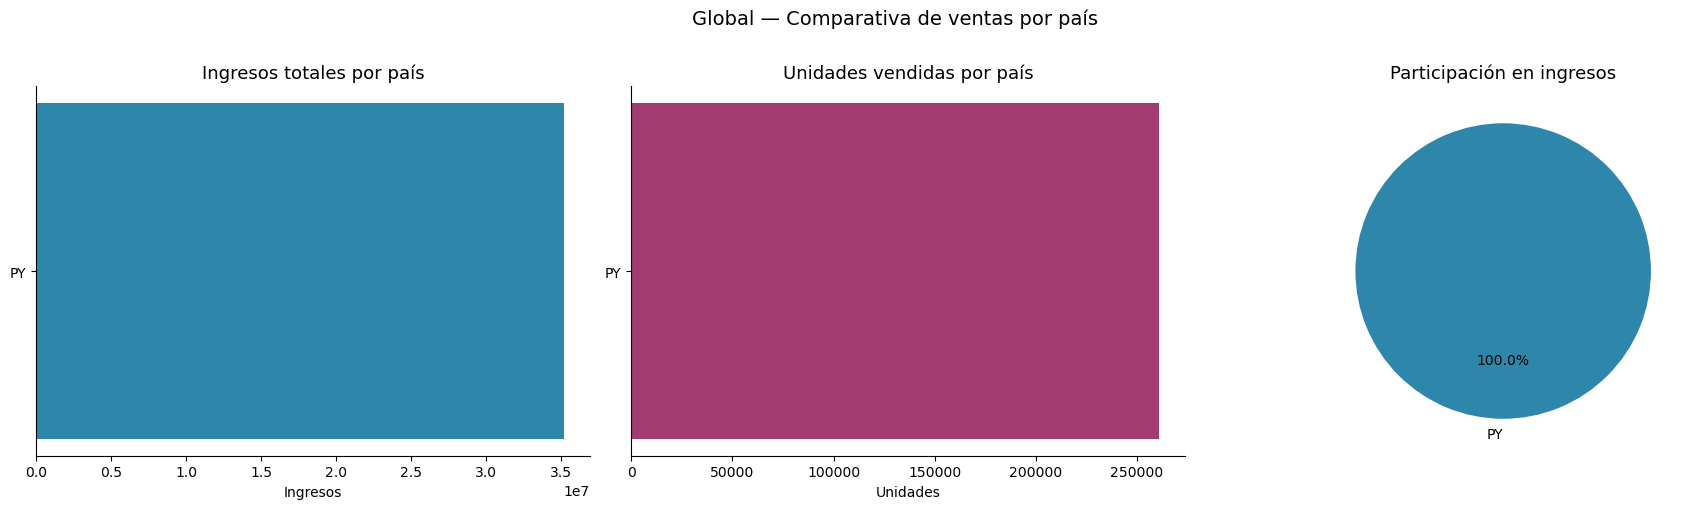

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(pivot_ventas["PAIS"][::-1], pivot_ventas["Ingresos totales"][::-1],
             color=COLORS[:len(pivot_ventas)])
axes[0].set_title("Ingresos totales por país")
axes[0].set_xlabel("Ingresos")

axes[1].barh(pivot_ventas["PAIS"][::-1], pivot_ventas["Unidades vendidas"][::-1],
             color=COLORS[1])
axes[1].set_title("Unidades vendidas por país")
axes[1].set_xlabel("Unidades")

axes[2].pie(pivot_ventas["PARTICIPACION_INGRESOS"],
            labels=pivot_ventas["PAIS"], autopct="%1.1f%%",
            colors=COLORS[:len(pivot_ventas)], startangle=90)
axes[2].set_title("Participación en ingresos")

plt.suptitle("Global — Comparativa de ventas por país", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "global_ventas_pais.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Evolución temporal global (todos los países)

In [ ]:
global_ventas_mes = pd.concat(acum_ventas_mes, ignore_index=True)
global_ventas_mes.to_csv(OUTPUT_DIR / "global_ventas_mensuales.csv", index=False)

# Serie global (suma todos los países)
serie_global = (
    global_ventas_mes
    .groupby("YEAR_MONTH", dropna=False)
    .agg(UNIDADES=("UNIDADES","sum"), INGRESOS=("INGRESOS","sum"))
    .reset_index().sort_values("YEAR_MONTH")
)
serie_global["CRECIMIENTO_INGRESOS_MOM"] = serie_global["INGRESOS"].pct_change()
display(serie_global)
serie_global.to_csv(OUTPUT_DIR / "global_serie_mensual.csv", index=False)


,YEAR_MONTH,UNIDADES,INGRESOS,CRECIMIENTO_INGRESOS_MOM
0,2023-01,9340,"1,288,815.38",NaN
1,2023-02,7396,"1,120,156.28",-0.13
2,2023-03,9813,"1,494,030.21",0.33
3,2023-04,8715,"1,151,157.79",-0.23
4,2023-05,11619,"1,440,533.59",0.25
5,2023-06,9010,"1,205,604.35",-0.16
6,2023-07,8932,"1,198,729.82",-0.01
7,2023-08,7998,"1,152,499.12",-0.04
8,2023-09,7054,"1,000,807.67",-0.13
9,2023-10,8411,"1,166,338.62",0.17


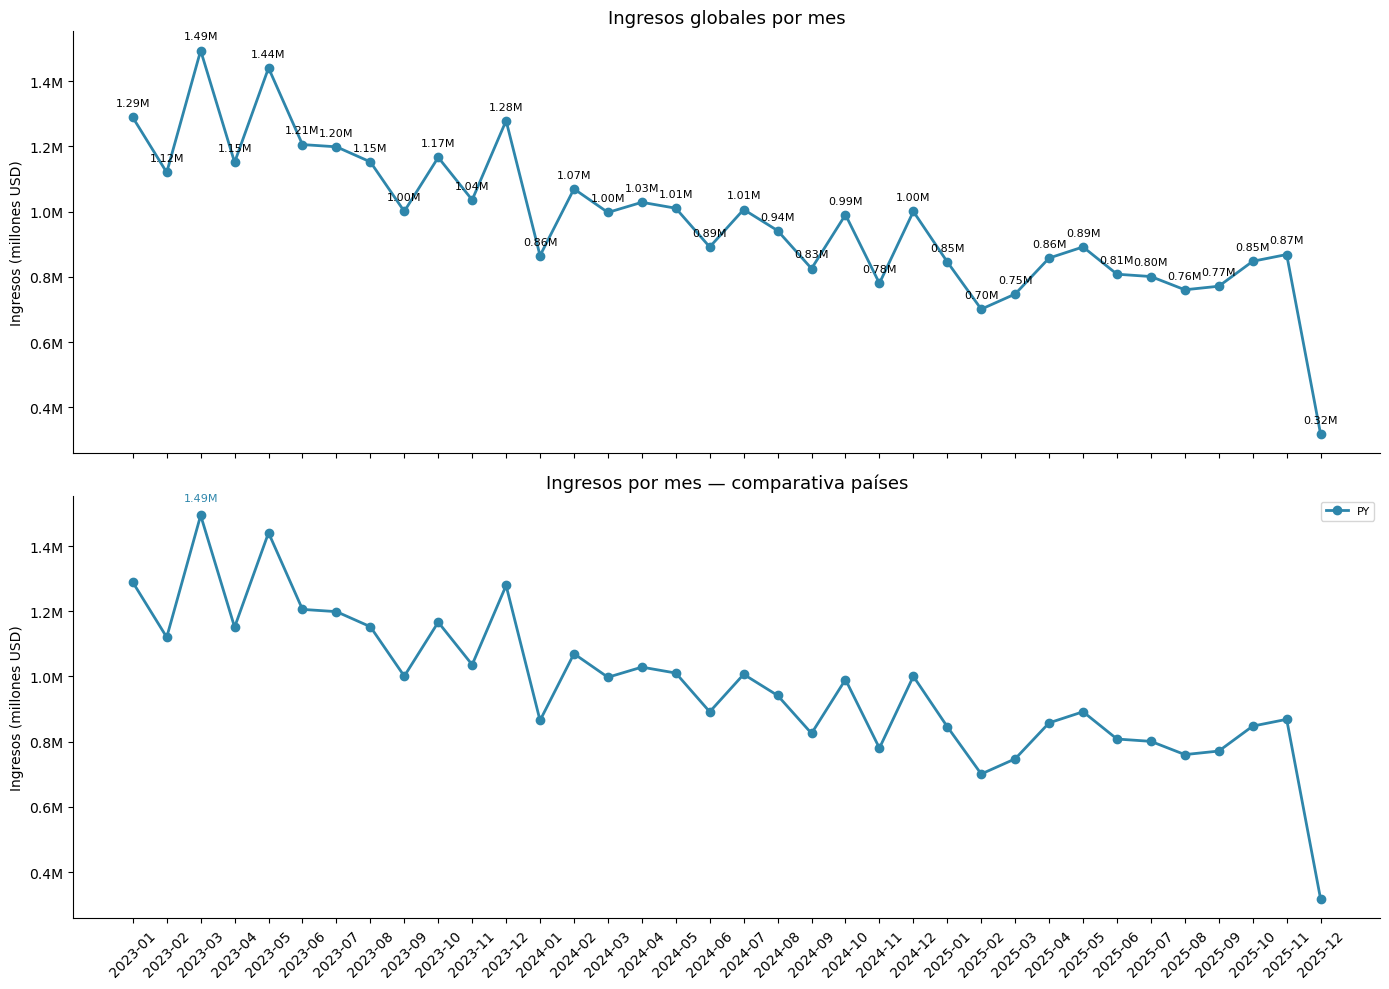

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── 1. GLOBAL ─────────────────────────────────────────────
axes[0].plot(
    serie_global["YEAR_MONTH"],
    serie_global["INGRESOS"],
    marker="o",
    color=COLORS[0],
    linewidth=2,
    label="Global"
)

axes[0].set_title("Ingresos globales por mes")
axes[0].tick_params(axis="x", rotation=45)

# 👇 formato en millones
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
axes[0].set_ylabel("Ingresos (millones USD)")

for x, y in zip(serie_global["YEAR_MONTH"], serie_global["INGRESOS"]):
    axes[0].annotate(
        f'{y/1e6:.2f}M',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

# ── 2. POR PAÍS ───────────────────────────────────────────
for i, pais in enumerate(PAISES):
    sub = global_ventas_mes[global_ventas_mes["PAIS"] == pais]

    axes[1].plot(
        sub["YEAR_MONTH"],
        sub["INGRESOS"],
        marker="o",
        label=pais,
        linewidth=2,
        color=COLORS[i % len(COLORS)]
    )

    if len(sub) > 0:
        idx_max = sub["INGRESOS"].idxmax()
        x_max = sub.loc[idx_max, "YEAR_MONTH"]
        y_max = sub.loc[idx_max, "INGRESOS"]

        axes[1].annotate(
            f'{y_max/1e6:.2f}M',
            (x_max, y_max),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=8,
            color=COLORS[i % len(COLORS)]
        )

axes[1].set_title("Ingresos por mes — comparativa países")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=8)

axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
axes[1].set_ylabel("Ingresos (millones USD)")

# ── FINAL ────────────────────────────────────────────────
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "global_ingresos_temporal.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.3 Crecimiento anual global

In [ ]:
global_anio = pd.concat(acum_ventas_anio, ignore_index=True)
global_anio.to_csv(OUTPUT_DIR / "global_ventas_anuales.csv", index=False)

# Tabla pivot por año y país
pivot_anio = global_anio.pivot_table(
    index="ANIO", columns="PAIS", values="INGRESOS", aggfunc="sum"
).reset_index()
pivot_anio.columns.name = None
display(pivot_anio)


,ANIO,PY
0,2023,"14,533,524.99"
1,2024,"11,407,219.80"
2,2025,"9,217,115.24"


### 5.4 KPIs de inventario global

In [ ]:
if acum_kpi_inv:
    global_inv = pd.concat(acum_kpi_inv, ignore_index=True)
    global_inv.to_csv(OUTPUT_DIR / "global_kpi_inventario.csv", index=False)

    resumen_inv_pais = (
        global_inv.groupby("PAIS", dropna=False)
        .agg(
            DOH_PROM=("DOH", "mean"),
            VENTAS_TOT=("VENTAS_UNIDADES", "sum"),
            INV_PROM_TOT=("INV_PROMEDIO", "sum"),
            INV_CIERRE_TOT=("INV_CIERRE", "sum")
        )
        .reset_index()
    )

    resumen_inv_pais["TURNOVER_GLOBAL"] = (
        resumen_inv_pais["VENTAS_TOT"] / resumen_inv_pais["INV_PROM_TOT"].replace(0, np.nan)
    )

    resumen_inv_pais["SELL_THROUGH_GLOBAL"] = (
        resumen_inv_pais["VENTAS_TOT"] /
        (resumen_inv_pais["VENTAS_TOT"] + resumen_inv_pais["INV_CIERRE_TOT"].replace(0, np.nan))
    )

    resumen_inv_pais = resumen_inv_pais.sort_values("DOH_PROM", ascending=False)

    display(resumen_inv_pais)
    resumen_inv_pais.to_csv(OUTPUT_DIR / "global_resumen_inventario_pais.csv", index=False)

,PAIS,DOH_PROM,VENTAS_TOT,INV_PROM_TOT,INV_CIERRE_TOT,TURNOVER_GLOBAL,SELL_THROUGH_GLOBAL
0,PY,68.90,260681,"536,895.48",549697,0.49,0.32


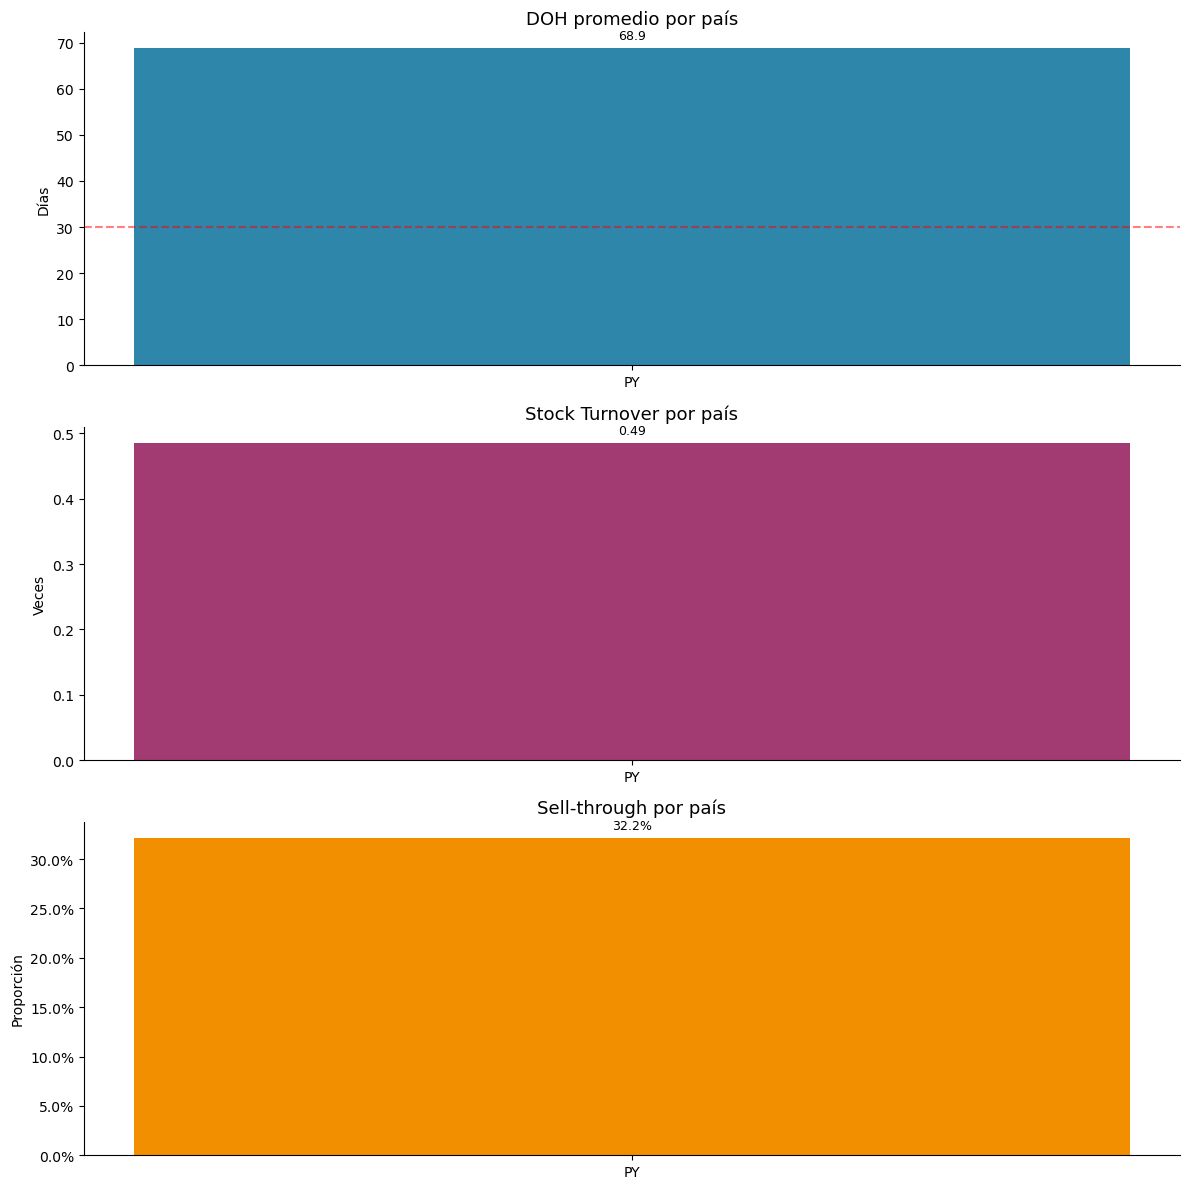

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# ── DOH ─────────────────────────────
axes[0].bar(resumen_inv_pais["PAIS"], resumen_inv_pais["DOH_PROM"], color=COLORS[0])
axes[0].axhline(y=30, linestyle="--", color="red", alpha=0.5)
axes[0].set_title("DOH promedio por país")
axes[0].set_ylabel("Días")
etiquetar_barras(axes[0], "{:,.1f}")

# ── TURNOVER ───────────────────────
axes[1].bar(resumen_inv_pais["PAIS"], resumen_inv_pais["TURNOVER_GLOBAL"], color=COLORS[1])
axes[1].set_title("Stock Turnover por país")
axes[1].set_ylabel("Veces")
etiquetar_barras(axes[1], "{:.2f}")

# ── SELL-THROUGH ───────────────────
axes[2].bar(resumen_inv_pais["PAIS"], resumen_inv_pais["SELL_THROUGH_GLOBAL"], color=COLORS[2])
axes[2].set_title("Sell-through por país")
axes[2].set_ylabel("Proporción")
format_porcentaje(axes[2], "y", escala=1.0)
etiquetar_barras(axes[2], "{:.1%}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kpi_inventario_por_pais.png", dpi=300, bbox_inches="tight")
plt.show()

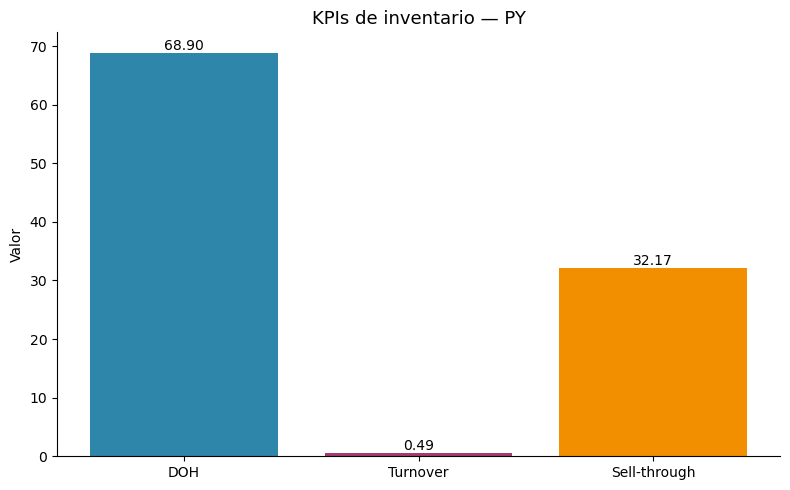

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

kpis = ["DOH", "Turnover", "Sell-through"]
valores = [
    resumen_inv_pais["DOH_PROM"].iloc[0],
    resumen_inv_pais["TURNOVER_GLOBAL"].iloc[0],
    resumen_inv_pais["SELL_THROUGH_GLOBAL"].iloc[0] * 100
]

ax.bar(kpis, valores, color=[COLORS[0], COLORS[1], COLORS[2]])

ax.set_title("KPIs de inventario — PY")
ax.set_ylabel("Valor")

for i, v in enumerate(valores):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 5.5 Stockout Rate y Fill Rate global

In [ ]:
if acum_stockout:
    global_so = pd.concat(acum_stockout, ignore_index=True)
    global_so.to_csv(OUTPUT_DIR / "global_stockout_rate.csv", index=False)

    so_pais = (
        global_so.groupby("PAIS", dropna=False)
        .agg(STOCKOUT_RATE_PROM=("STOCKOUT_RATE", "mean"))
        .reset_index()
    )

    skus_stockout = (
        global_so[global_so["STOCKOUT_RATE"] > 0]
        .groupby("PAIS", dropna=False)["CODIGO_SKU"]
        .nunique()
        .reset_index(name="SKUS_CON_STOCKOUT")
    )

    so_pais = so_pais.merge(skus_stockout, on="PAIS", how="left")
    so_pais["SKUS_CON_STOCKOUT"] = so_pais["SKUS_CON_STOCKOUT"].fillna(0).astype(int)

    display(so_pais)
    so_pais.to_csv(OUTPUT_DIR / "global_stockout_rate_pais.csv", index=False)

if acum_fill_rate:
    global_fr = pd.concat(acum_fill_rate, ignore_index=True)
    global_fr.to_csv(OUTPUT_DIR / "global_fill_rate.csv", index=False)

    fr_pais = (
        global_fr.groupby("PAIS", dropna=False)
        .agg(FILL_RATE_PROM=("FILL_RATE", "mean"))
        .reset_index()
    )

    display(fr_pais)
    fr_pais.to_csv(OUTPUT_DIR / "global_fill_rate_pais.csv", index=False)

,PAIS,STOCKOUT_RATE_PROM,SKUS_CON_STOCKOUT
0,PY,0.32,301


,PAIS,FILL_RATE_PROM
0,PY,0.27


### 5.6 Top marcas global

In [ ]:
global_marca = pd.concat(acum_marca, ignore_index=True)
global_marca.to_csv(OUTPUT_DIR / "global_todas_marcas.csv", index=False)

ranking_marca = (
    global_marca.groupby("MARCA", dropna=False)
    .agg(UNIDADES=("UNIDADES","sum"), INGRESOS=("INGRESOS","sum"),
         ASP=("ASP","mean"), PAISES=("PAIS","nunique"))
    .reset_index().sort_values("UNIDADES", ascending=False)
)
ranking_marca["PARTICIPACION_UNIDADES"] = ranking_marca["UNIDADES"] / ranking_marca["UNIDADES"].sum()
ranking_marca["PARTICIPACION_INGRESOS"] = ranking_marca["INGRESOS"] / ranking_marca["INGRESOS"].sum()
display(ranking_marca)
ranking_marca.to_csv(OUTPUT_DIR / "global_ranking_marcas.csv", index=False)


,MARCA,UNIDADES,INGRESOS,ASP,PAISES,PARTICIPACION_UNIDADES,PARTICIPACION_INGRESOS
10,SAMSUNG,136500,"18,813,001.34",247.50,1,0.52,0.54
4,HONOR,35968,"4,011,841.94",172.90,1,0.14,0.11
11,TECNO,28486,"2,021,337.31",97.47,1,0.11,0.06
0,APPLE,14865,"7,318,899.77",566.71,1,0.06,0.21
7,MOTOROLA,11714,"1,076,685.28",142.58,1,0.04,0.03
1,BLU,10998,"331,594.02",54.53,1,0.04,0.01
3,BOLD,6589,"169,458.54",42.38,1,0.03,0.00
9,OPPO,4914,"522,037.66",138.68,1,0.02,0.01
5,HUAWEI,4076,"515,321.78",158.76,1,0.02,0.01
8,NOKIA,3324,"176,171.95",79.69,1,0.01,0.01


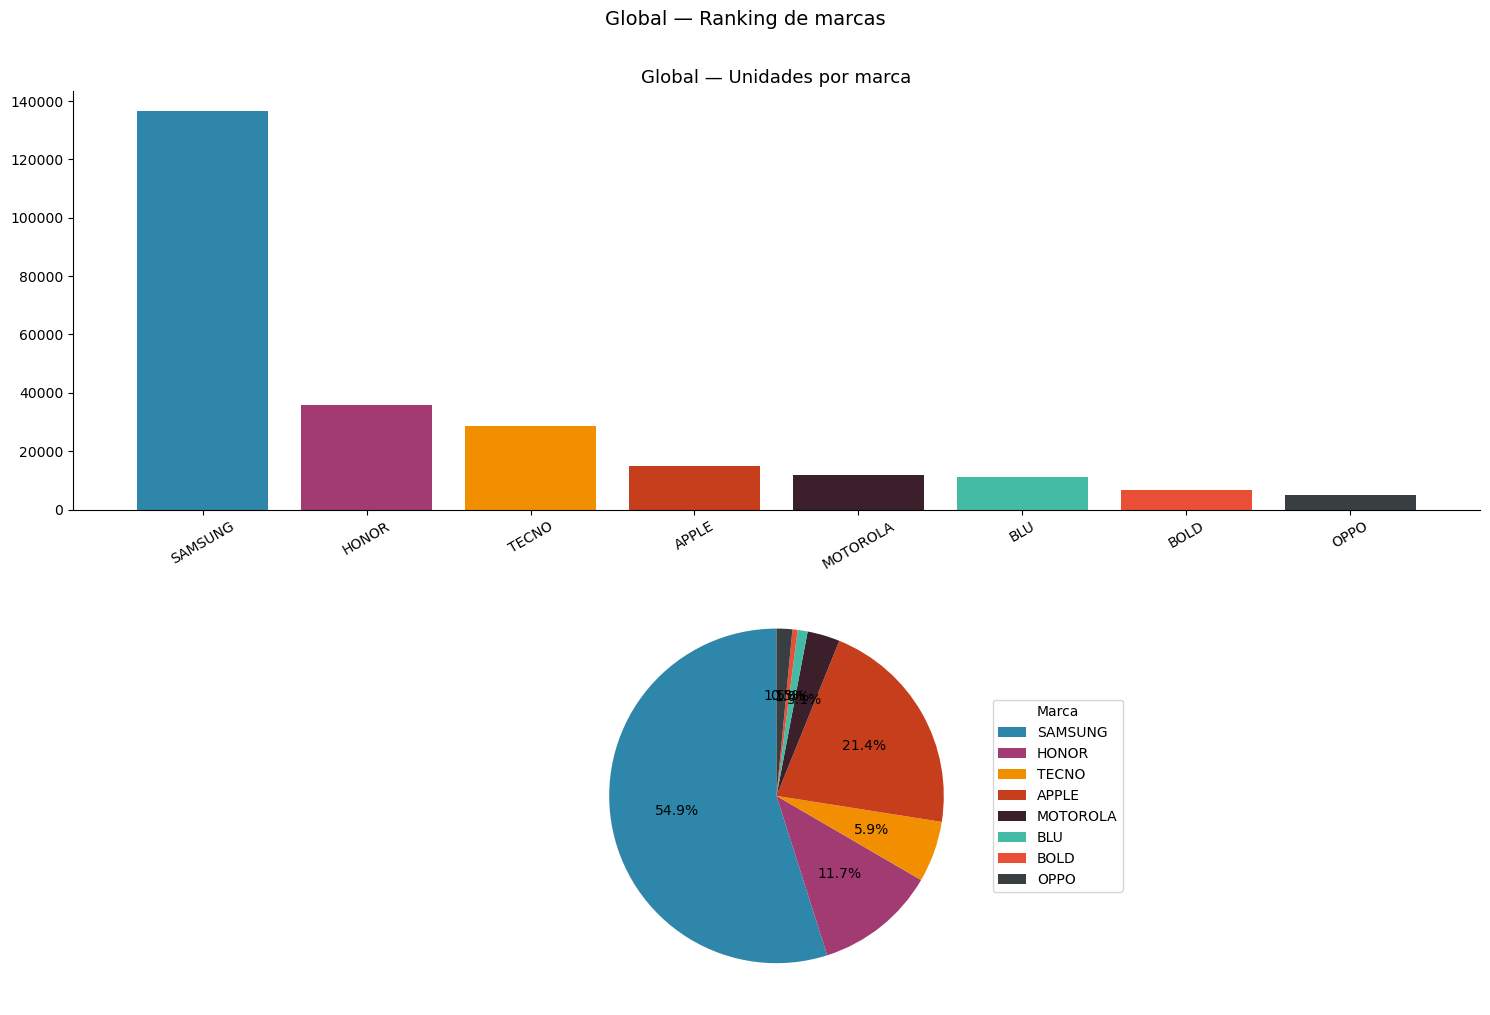

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

top8 = ranking_marca.head(8)
axes[0].bar(top8["MARCA"], top8["UNIDADES"], color=COLORS[:len(top8)])
axes[0].set_title("Global — Unidades por marca")
axes[0].tick_params(axis="x", rotation=30)

wedges, texts, autotexts = axes[1].pie(
    top8["PARTICIPACION_INGRESOS"],
    autopct="%1.1f%%",
    startangle=90,
    colors=COLORS[:len(top8)]
)

axes[1].legend(
    wedges,
    top8["MARCA"],
    title="Marca",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.suptitle("Global — Ranking de marcas", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "global_marcas.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.7 Top modelos global

In [ ]:
global_modelos = pd.concat(acum_modelos, ignore_index=True)

ranking_modelos = (
    global_modelos.groupby(["MODELO","MARCA","TIER"], dropna=False)
    .agg(UNIDADES=("UNIDADES","sum"), INGRESOS=("INGRESOS","sum"),
         ASP=("ASP","mean"), PAISES=("PAIS","nunique"))
    .reset_index().sort_values("UNIDADES", ascending=False).head(20)
)
display(ranking_modelos)
ranking_modelos.to_csv(OUTPUT_DIR / "global_top20_modelos.csv", index=False)


,MODELO,MARCA,TIER,UNIDADES,INGRESOS,ASP,PAISES
11,SAMSUNG A54 5G 6GB+128GB BLACK,SAMSUNG,HIGH,10523,"2,247,732.51",301.59,1
8,SAMSUNG A15 4GB+128GB BLACK,SAMSUNG,MID,9444,"554,638.56",113.24,1
2,SAMSUNG A04 4+128 GB,SAMSUNG,MID,8962,"554,700.00",102.23,1
13,SAMSUNG GALAXY A05 4GB+64GB BLACK,SAMSUNG,MID,8542,"75,254.32",46.65,1
7,SAMSUNG A14 4GB+128GB,SAMSUNG,MID,7293,"427,843.24",115.62,1
5,SAMSUNG A06 4GB+128GB,SAMSUNG,MID,7272,"319,056.12",82.26,1
3,SAMSUNG A04 4+64 GB,SAMSUNG,MID,7187,"377,454.00",100.28,1
1,HONOR X7C 8GB+256GB BLACK,HONOR,MID,6570,"497,059.72",118.94,1
10,SAMSUNG A24 4GB+128GB,SAMSUNG,MID HIGH,6467,"742,900.98",178.15,1
12,SAMSUNG A55 5G 8GB+256GB BLACK,SAMSUNG,HIGH,6256,"1,327,140.89",298.81,1


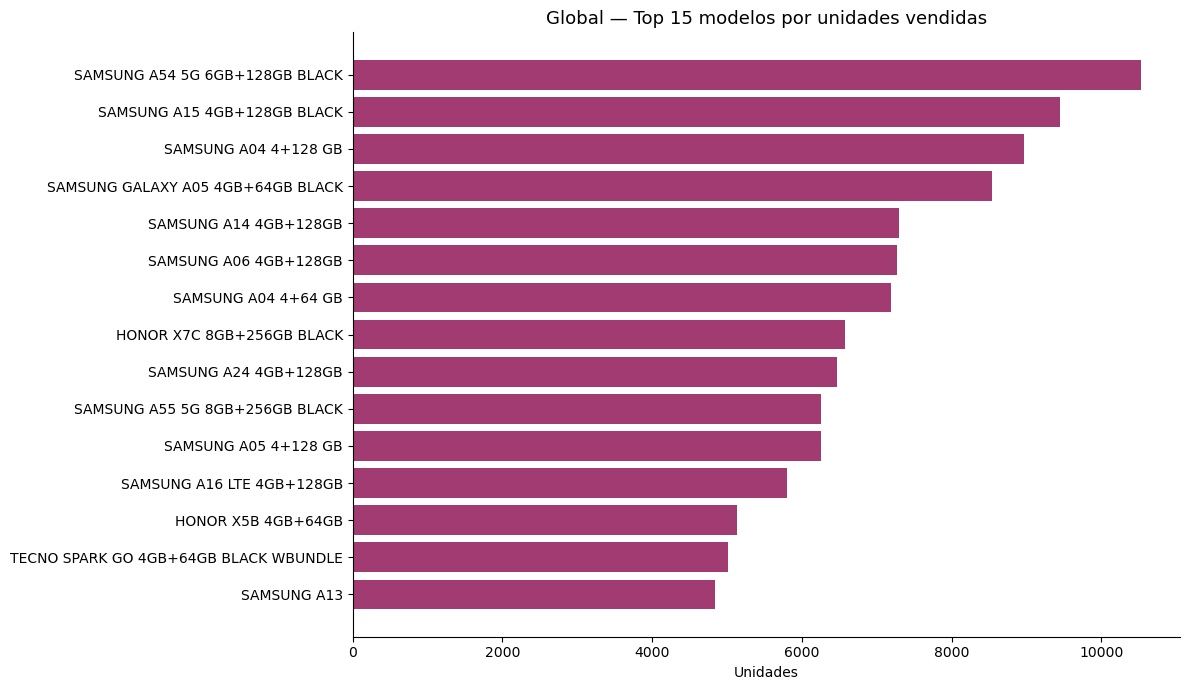

In [ ]:
top15 = ranking_modelos.head(15)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top15["MODELO"][::-1], top15["UNIDADES"][::-1], color=COLORS[1])
ax.set_title("Global — Top 15 modelos por unidades vendidas")
ax.set_xlabel("Unidades")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "global_top15_modelos.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.8 KPIs por tier global

In [ ]:
global_tier = pd.concat(acum_tier, ignore_index=True)

ranking_tier = (
    global_tier.groupby("TIER", dropna=False)
    .agg(UNIDADES=("UNIDADES","sum"), INGRESOS=("INGRESOS","sum"),
         ASP=("ASP","mean"), PAISES=("PAIS","nunique"))
    .reset_index().sort_values("UNIDADES", ascending=False)
)
ranking_tier["PARTICIPACION_UNIDADES"] = ranking_tier["UNIDADES"] / ranking_tier["UNIDADES"].sum()
ranking_tier["PARTICIPACION_INGRESOS"] = ranking_tier["INGRESOS"] / ranking_tier["INGRESOS"].sum()
display(ranking_tier)
ranking_tier.to_csv(OUTPUT_DIR / "global_kpi_tier.csv", index=False)


,TIER,UNIDADES,INGRESOS,ASP,PAISES,PARTICIPACION_UNIDADES,PARTICIPACION_INGRESOS
6,MID,123292,"7,305,527.57",106.80,1,0.47,0.21
4,HIGH,33535,"7,560,026.84",309.43,1,0.13,0.22
8,MID LOW,28827,"1,128,185.45",68.52,1,0.11,0.03
7,MID HIGH,24884,"3,539,587.23",199.11,1,0.10,0.10
3,FLAGSHIP,22915,"11,779,860.83",588.95,1,0.09,0.34
5,LOW,19730,"627,178.10",61.05,1,0.08,0.02
10,ULTRA HIGH,7457,"3,216,511.48",517.81,1,0.03,0.09
9,MODEMS,34,564.06,23.26,1,0.00,0.00
0,CPE CORPO,3,192.12,64.04,1,0.00,0.00
1,CPE HOME,3,176.86,66.32,1,0.00,0.00


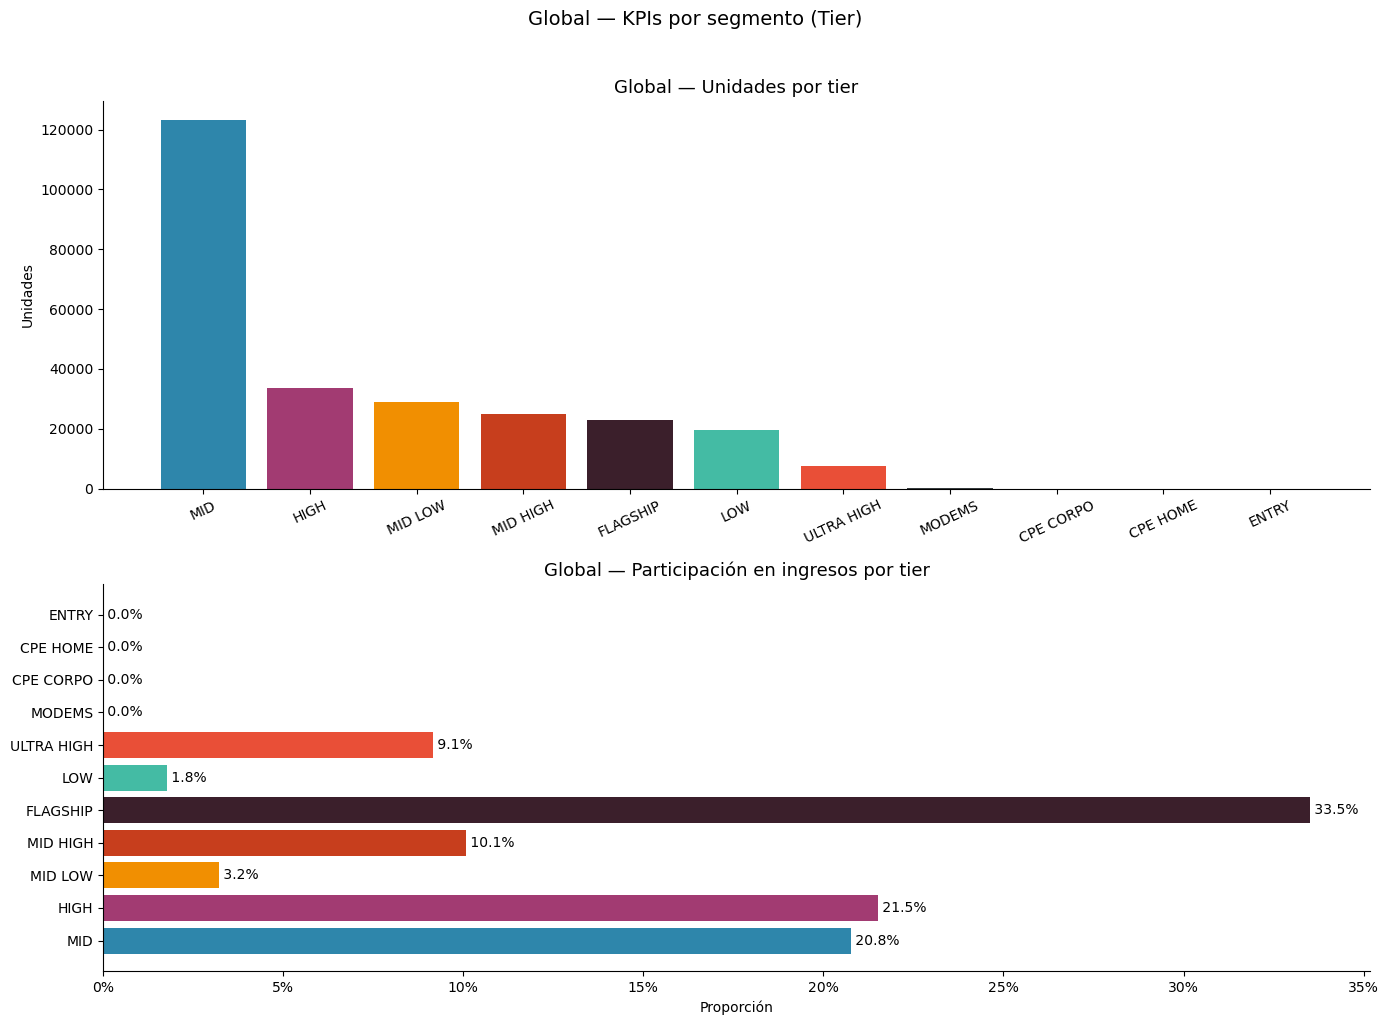

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
c = COLORS[:len(ranking_tier)]

# ── 1. UNIDADES ─────────────────────────────
axes[0].bar(ranking_tier["TIER"], ranking_tier["UNIDADES"], color=c)
axes[0].set_title("Global — Unidades por tier")
axes[0].set_ylabel("Unidades")
axes[0].tick_params(axis="x", rotation=25)

# ── 2. PARTICIPACIÓN (MEJOR QUE PIE) ───────
axes[1].barh(
    ranking_tier["TIER"],
    ranking_tier["PARTICIPACION_INGRESOS"],
    color=c
)

axes[1].set_title("Global — Participación en ingresos por tier")
axes[1].set_xlabel("Proporción")

# formato %
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0%}')
)

# etiquetas
for i, v in enumerate(ranking_tier["PARTICIPACION_INGRESOS"]):
    axes[1].text(v, i, f' {v:.1%}', va='center')

plt.suptitle("Global — KPIs por segmento (Tier)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "global_tier.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.9 Tabla ejecutiva global

In [ ]:
tabla_ejecutiva_global = (
    df_sales
    .groupby(["PAIS","ANIO","YEAR_MONTH"], dropna=False)
    .agg(
        UNIDADES        = ("VALUE",          "sum"),
        INGRESOS        = ("INGRESO_TOTAL",  "sum"),
        ASP             = ("PRECIO_UNITARIO","mean"),
        SKUS_ACTIVOS    = ("CODIGO_SKU",     "nunique"),
        BODEGAS_ACTIVAS = ("CODIGO_BODEGA",  "nunique")
    )
    .reset_index()
    .sort_values(["PAIS","YEAR_MONTH"])
)

tabla_ejecutiva_global["CRECIMIENTO_INGRESOS_MOM"] = (
    tabla_ejecutiva_global.groupby("PAIS")["INGRESOS"].pct_change()
)

display(tabla_ejecutiva_global.head(25))
tabla_ejecutiva_global.to_csv(OUTPUT_DIR / "global_tabla_ejecutiva.csv", index=False)
print(f"Tabla ejecutiva global: {len(tabla_ejecutiva_global):,} filas exportadas.")


,PAIS,ANIO,YEAR_MONTH,UNIDADES,INGRESOS,ASP,SKUS_ACTIVOS,BODEGAS_ACTIVAS,CRECIMIENTO_INGRESOS_MOM
0,PY,2023,2023-01,9340,"1,288,815.38",199.87,72,94,NaN
1,PY,2023,2023-02,7396,"1,120,156.28",217.42,72,95,-0.13
2,PY,2023,2023-03,9813,"1,494,030.21",218.47,72,94,0.33
3,PY,2023,2023-04,8715,"1,151,157.79",212.44,74,92,-0.23
4,PY,2023,2023-05,11619,"1,440,533.59",206.70,79,96,0.25
5,PY,2023,2023-06,9010,"1,205,604.35",213.94,82,92,-0.16
6,PY,2023,2023-07,8932,"1,198,729.82",208.98,82,91,-0.01
7,PY,2023,2023-08,7998,"1,152,499.12",219.05,89,87,-0.04
8,PY,2023,2023-09,7054,"1,000,807.67",215.29,76,84,-0.13
9,PY,2023,2023-10,8411,"1,166,338.62",219.28,72,86,0.17


Tabla ejecutiva global: 36 filas exportadas.
